# Olist Marketplace Growth, Retention, and Customer Value Strategy

This project is an end-to-end marketplace analytics case study built using the Brazilian Olist e-commerce dataset.

The main goal is to understand how marketplace growth, customer retention, logistics performance, and customer value interact from both a business and operational perspective. Instead of focusing only on exploratory analysis, the notebook approaches the dataset as a real marketplace strategy problem, combining commercial analytics, customer behavior analysis, experimentation, and predictive modeling.

The analysis is structured around the kinds of questions a product manager, growth analyst, or marketplace operator would need to answer in order to improve long-term marketplace performance.

# Executive Summary

This project analyzes the Brazilian Olist marketplace to understand the main drivers of growth, customer value, retention, logistics performance, and operational quality.

The analysis combines marketplace KPI modeling, cohort retention analysis, customer lifetime value segmentation, experimentation concepts, and lightweight predictive modeling to evaluate both commercial performance and long-term marketplace sustainability.

### Main Findings

- Marketplace GMV is diversified across categories, although a relatively small group of sellers and customer segments still explains most commercial activity.
- Retention is the marketplace’s main structural weakness: only 3.0% of customers place more than one order, and month-1 cohort retention is approximately 5.2%.
- Customer value is highly concentrated, with the highest-value customer segment contributing nearly 60% of total GMV.
- Logistics quality directly affects customer experience, since late deliveries and longer shipping routes are consistently associated with weaker review scores.
- Categories such as `health_beauty` and `sports_leisure` combine scale and customer satisfaction, while large home-related categories show stronger operational friction.
- A simulated retention experiment suggests that discount campaigns may improve conversion, but generate limited short-term GMV impact once discount costs are considered.

Overall, the results suggest that the marketplace’s largest long-term opportunity is not increasing basket size, but improving customer retention, delivery reliability, and operational quality across strategically important categories and sellers.

# 1. Business Understanding

Olist operates as a marketplace infrastructure platform, which means sustainable growth depends not only on increasing transaction volume, but also on maintaining strong customer experience, seller quality, and operational efficiency.

Because of that, this analysis focuses on understanding how commercial growth, retention behavior, logistics performance, and customer value interact across the marketplace ecosystem.

The objective is not only to measure marketplace performance, but also to identify where operational friction and customer experience issues may limit long-term growth.

### Core business questions

1. Which categories, sellers, and customer regions contribute the most to marketplace GMV?
2. Is marketplace growth primarily driven by customer acquisition or repeat purchasing behavior?
3. How concentrated is marketplace value across customers, sellers, and product categories?
4. Which operational factors appear to negatively affect customer satisfaction and retention?
5. Could a discount-based retention strategy improve repeat purchasing behavior in a financially sustainable way?

### Working hypotheses

1. Marketplace GMV is highly concentrated among a relatively small group of sellers and product categories.
2. Longer shipping distances and delivery delays negatively affect customer satisfaction and repeat purchasing behavior.
3. Customer value distribution is highly skewed, with a minority of customers generating a disproportionate share of marketplace GMV.
4. Retention incentives may increase short-term conversion rates, but their long-term incremental GMV impact is likely more nuanced once discount costs are considered.

# Business Objectives

The project focuses on five main business questions:

- Understand what drives marketplace GMV and how marketplace value is concentrated across customers, sellers, and categories.
- Identify why retention remains weak and where customer experience breaks down.
- Estimate customer value and identify high-priority customer segments.
- Simulate retention-oriented interventions and evaluate conversion vs GMV trade-offs.
- Translate analytical findings into realistic product, growth, and operational recommendations.

> **GMV note:** Throughout this notebook, GMV is used as a proxy for marketplace transaction volume, calculated as item price plus freight value. The dataset does not provide Olist's actual platform revenue, commissions, contribution margins, or operational costs.

# 2. Environment Setup

This section initializes the analytical environment used throughout the notebook, including libraries, visualization settings, display formatting, and helper functions used for feature engineering and business analysis.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)

pd.set_option(
    "display.max_columns",
    100,
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.2f}",
)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

def mode_or_first(series):

    series = series.dropna()

    if series.empty:
        return np.nan

    mode = series.mode()

    return (
        mode.iat[0]
        if not mode.empty
        else series.iloc[0]
    )


def haversine_km(
    lat1,
    lon1,
    lat2,
    lon2,
):

    lat1 = np.radians(lat1.astype(float))
    lon1 = np.radians(lon1.astype(float))
    lat2 = np.radians(lat2.astype(float))
    lon2 = np.radians(lon2.astype(float))

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return (
        6371
        * 2
        * np.arcsin(np.sqrt(a))
    )

# 3. Data Preparation

This dataset is distributed across multiple relational tables, so the first step is to consolidate customers, orders, products, sellers, payments, reviews, and geolocation data into a unified analytical structure.

To keep the analysis flexible, I build the marketplace at three different levels of granularity:

- an **item-level** table for product, seller, and logistics analysis
- an **order-level** table for GMV and customer behavior analysis
- a **customer-level** table for retention, segmentation, and LTV analysis

In [2]:
DATA_DIR = Path("olist_data")

assert DATA_DIR.exists(), (
    "Local folder 'olist_data' was not found."
)

customers = pd.read_csv(
    DATA_DIR / "olist_customers_dataset.csv"
)

geolocation = pd.read_csv(
    DATA_DIR / "olist_geolocation_dataset.csv"
)

order_items = pd.read_csv(
    DATA_DIR / "olist_order_items_dataset.csv",
    parse_dates=["shipping_limit_date"],
)

payments = pd.read_csv(
    DATA_DIR / "olist_order_payments_dataset.csv"
)

reviews = pd.read_csv(
    DATA_DIR / "olist_order_reviews_dataset.csv",
    parse_dates=[
        "review_creation_date",
        "review_answer_timestamp",
    ],
)

orders = pd.read_csv(
    DATA_DIR / "olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)

products = pd.read_csv(
    DATA_DIR / "olist_products_dataset.csv"
)

sellers = pd.read_csv(
    DATA_DIR / "olist_sellers_dataset.csv"
)

category_translation = pd.read_csv(
    DATA_DIR / "product_category_name_translation.csv"
)

datasets = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation,
}

dataset_overview = (
    pd.DataFrame(
        [
            {
                "dataset": name,
                "rows": frame.shape[0],
                "columns": frame.shape[1],
            }
            for name, frame in datasets.items()
        ]
    )
    .sort_values("dataset")
    .reset_index(drop=True)
)

display(dataset_overview)

purchase_start = (
    orders["order_purchase_timestamp"]
    .min()
    .strftime("%Y-%m-%d")
)

purchase_end = (
    orders["order_purchase_timestamp"]
    .max()
    .strftime("%Y-%m-%d")
)

display(
    Markdown(
        f"""
> **Purchase coverage:** {purchase_start} to {purchase_end}
"""
    )
)

,dataset,rows,columns
0,category_translation,71,2
1,customers,99441,5
2,geolocation,1000163,5
3,order_items,112650,7
4,orders,99441,8
5,payments,103886,5
6,products,32951,9
7,reviews,99224,7
8,sellers,3095,4



> **Purchase coverage:** 2016-09-04 to 2018-10-17


> Interpretation
> * The marketplace data is distributed across multiple operational tables covering customers, orders, payments, reviews, sellers, products, and geolocation information.
> * The dataset contains nearly 100k orders and more than 1 million geolocation records, enabling both commercial and logistics-oriented analysis.
> * Purchase activity spans from 2016 to 2018, providing enough historical coverage to evaluate marketplace growth, retention, and customer behavior patterns.

## 3.1 Data Integration and Enrichment

The original Olist dataset is distributed across multiple transactional tables, including customers, sellers, products, payments, reviews, and geolocation data.

This step consolidates those sources into enriched analytical datasets that connect commercial, geographic, and customer-level information into a unified structure suitable for downstream analysis.

In [3]:
products = products.merge(
    category_translation,
    on="product_category_name",
    how="left",
)

products["product_category_name"] = (
    products["product_category_name"]
    .fillna("unknown")
)

products["product_category_name_english"] = (
    products["product_category_name_english"]
    .fillna("unknown")
)

geo_zip = (
    geolocation.groupby(
        "geolocation_zip_code_prefix",
        as_index=False,
    )
    .agg(
        geolocation_lat=("geolocation_lat", "mean"),
        geolocation_lng=("geolocation_lng", "mean"),
        geolocation_city=("geolocation_city", mode_or_first),
        geolocation_state=("geolocation_state", mode_or_first),
    )
)

customer_geo = geo_zip.rename(
    columns={
        "geolocation_zip_code_prefix": "customer_zip_code_prefix",
        "geolocation_lat": "customer_lat",
        "geolocation_lng": "customer_lng",
        "geolocation_city": "customer_geo_city",
        "geolocation_state": "customer_geo_state",
    }
)

seller_geo = geo_zip.rename(
    columns={
        "geolocation_zip_code_prefix": "seller_zip_code_prefix",
        "geolocation_lat": "seller_lat",
        "geolocation_lng": "seller_lng",
        "geolocation_city": "seller_geo_city",
        "geolocation_state": "seller_geo_state",
    }
)

customers_enriched = customers.merge(
    customer_geo,
    on="customer_zip_code_prefix",
    how="left",
)

sellers_enriched = sellers.merge(
    seller_geo,
    on="seller_zip_code_prefix",
    how="left",
)

payments_agg = (
    payments.groupby(
        "order_id",
        as_index=False,
    )
    .agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max"),
        payment_type=("payment_type", mode_or_first),
        payment_type_nunique=("payment_type", "nunique"),
    )
)

reviews_agg = (
    reviews.groupby(
        "order_id",
        as_index=False,
    )
    .agg(
        review_score=("review_score", "mean"),
        review_comment_rate=(
            "review_comment_message",
            lambda s: s.notna().mean(),
        ),
        review_count=("review_id", "nunique"),
    )
)

orders_enriched = (
    orders
    .merge(
        customers_enriched,
        on="customer_id",
        how="left",
    )
    .merge(
        payments_agg,
        on="order_id",
        how="left",
    )
    .merge(
        reviews_agg,
        on="order_id",
        how="left",
    )
)

> Interpretation
> * Transactional, customer, payment, review, and geolocation tables were consolidated into a unified analytical structure.
> * ZIP-level geolocation enrichment enables downstream logistics and distance-based analysis between customers and sellers.
> * Payment and review data were aggregated at the order level to reduce duplication and improve consistency across marketplace metrics.
> * This enriched structure becomes the foundation for customer behavior analysis, operational diagnostics, retention evaluation, and LTV modeling throughout the notebook.

## 3.2 Order-Level Feature Engineering

At this stage, the analysis moves from raw transactional records to a structured order-level analytical dataset.

The goal is to create commercial, operational, and logistics-related features that better represent marketplace behavior and customer experience. This includes delivery performance, freight participation, shipping distance, seller concentration, and aggregated GMV metrics.

### 3.2.1 Delivery and Time-Based Features

The first step focuses on delivery performance and operational timing metrics derived directly from the order lifecycle timestamps.

These features help measure shipping efficiency, approval delays, delivery punctuality, and purchase seasonality, which are important drivers of customer experience and retention behavior.

In [4]:
orders_enriched["delivery_days"] = (
    orders_enriched["order_delivered_customer_date"]
    - orders_enriched["order_purchase_timestamp"]
).dt.days

orders_enriched["estimated_vs_actual_days"] = (
    orders_enriched["order_delivered_customer_date"]
    - orders_enriched["order_estimated_delivery_date"]
).dt.days

orders_enriched["approval_lag_hours"] = (
    orders_enriched["order_approved_at"]
    - orders_enriched["order_purchase_timestamp"]
).dt.total_seconds() / 3600

orders_enriched["is_late_delivery"] = (
    orders_enriched["estimated_vs_actual_days"] > 0
).astype(int)

orders_enriched["purchase_month"] = (
    orders_enriched["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

display(
    orders_enriched[
        [
            "order_id",
            "delivery_days",
            "estimated_vs_actual_days",
            "approval_lag_hours",
            "is_late_delivery",
            "purchase_month",
        ]
    ]
    .assign(
        is_late_delivery=lambda x: (
            x["is_late_delivery"].astype(int)
        )
    )
    .round(
        {
            "delivery_days": 1,
            "estimated_vs_actual_days": 1,
            "approval_lag_hours": 2,
        }
    )
    .head()
)

,order_id,delivery_days,estimated_vs_actual_days,approval_lag_hours,is_late_delivery,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,8.00,-8.00,0.18,0,2017-10-01
1,53cdb2fc8bc7dce0b6741e2150273451,13.00,-6.00,30.71,0,2018-07-01
2,47770eb9100c2d0c44946d9cf07ec65d,9.00,-18.00,0.28,0,2018-08-01
3,949d5b44dbf5de918fe9c16f97b45f8a,13.00,-13.00,0.30,0,2017-11-01
4,ad21c59c0840e6cb83a9ceb5573f8159,2.00,-10.00,1.03,0,2018-02-01


> Interpretation
> * Delivery and approval timestamps were transformed into operational performance indicators at the order level.
> * Features such as delivery duration, approval lag, and late delivery flags help quantify logistics efficiency and fulfillment quality.
> * Monthly purchase timestamps were also standardized to support marketplace growth and seasonality analysis in later sections.
> * These variables create the temporal foundation for retention, customer experience, and operational performance evaluation.

### 3.2.2 Item-Level Commercial and Logistics Features

This step enriches the transactional item-level dataset with commercial, product, and seller-related information.

The objective is to create granular operational features that capture freight participation, product size, and marketplace routing structure before introducing geographic distance calculations and order-level aggregation.

In [5]:
order_item_base = (
    order_items
    .merge(
        products,
        on="product_id",
        how="left",
    )
    .merge(
        sellers_enriched,
        on="seller_id",
        how="left",
    )
    .merge(
        orders_enriched,
        on="order_id",
        how="left",
        suffixes=("", "_order"),
    )
)

order_item_base["item_gmv"] = (
    order_item_base["price"]
    + order_item_base["freight_value"]
)

order_item_base["freight_share"] = (
    order_item_base["freight_value"]
    / order_item_base["item_gmv"]
)

order_item_base["volume_cm3"] = (
    order_item_base["product_length_cm"].fillna(0)
    * order_item_base["product_height_cm"].fillna(0)
    * order_item_base["product_width_cm"].fillna(0)
)

order_item_base["same_state_route"] = (
    order_item_base["customer_state"]
    == order_item_base["seller_state"]
).astype(int)

display(
    order_item_base[
        [
            "order_id",
            "product_category_name_english",
            "item_gmv",
            "freight_share",
            "volume_cm3",
            "same_state_route",
        ]
    ]
    .round(
        {
            "item_gmv": 2,
            "freight_share": 2,
            "volume_cm3": 0,
        }
    )
    .head()
)

,order_id,product_category_name_english,item_gmv,freight_share,volume_cm3,same_state_route
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,72.19,0.18,"3,528.00",0
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,259.83,0.08,"60,000.00",1
2,000229ec398224ef6ca0657da4fc703e,furniture_decor,216.87,0.08,"14,157.00",1
3,00024acbcdf0a6daa1e931b038114c75,perfumery,25.78,0.50,"2,400.00",1
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools,218.04,0.08,"42,000.00",0


> Interpretation
> * Item-level transactional records were enriched with commercial and logistics-related information.
> * Features such as freight participation, product volume, and intra-state routing help capture operational complexity and shipping structure across marketplace transactions.
> * The integration of customer, seller, and product information creates a granular analytical layer suitable for GMV, freight, seller, and category-level analysis.
> * This enriched item-level dataset becomes the operational foundation for later marketplace aggregation and performance evaluation steps.

### 3.2.3 Geographic Distance Features

This step introduces geographic distance estimation between customers and sellers using ZIP-level latitude and longitude coordinates.

The objective is to approximate shipping distance and logistics complexity across marketplace transactions, enabling later analysis of freight costs, delivery performance, and customer experience deterioration.

In [6]:
distance_mask = order_item_base[
    [
        "customer_lat",
        "customer_lng",
        "seller_lat",
        "seller_lng",
    ]
].notna().all(axis=1)

order_item_base["distance_km"] = np.nan

order_item_base.loc[
    distance_mask,
    "distance_km",
] = haversine_km(
    order_item_base.loc[
        distance_mask,
        "customer_lat",
    ],
    order_item_base.loc[
        distance_mask,
        "customer_lng",
    ],
    order_item_base.loc[
        distance_mask,
        "seller_lat",
    ],
    order_item_base.loc[
        distance_mask,
        "seller_lng",
    ],
)

display(
    order_item_base[
        [
            "order_id",
            "customer_state",
            "seller_state",
            "distance_km",
        ]
    ]
    .round(
        {
            "distance_km": 1,
        }
    )
    .head()
)

,order_id,customer_state,seller_state,distance_km
0,00010242fe8c5a6d1ba2dd792cb16214,RJ,SP,301.50
1,00018f77f2f0320c557190d7a144bdd3,SP,SP,585.60
2,000229ec398224ef6ca0657da4fc703e,MG,MG,312.30
3,00024acbcdf0a6daa1e931b038114c75,SP,SP,293.20
4,00042b26cf59d7ce69dfabb4e55b4fd9,SP,PR,646.20


> Interpretation
> * Customer and seller geolocation data were combined to estimate shipping distance at the transactional level using the Haversine formula.
> * Distance metrics help capture logistical complexity and marketplace coverage across Brazilian states and regions.
> * Cross-state routes generally involve longer shipping distances and potentially higher operational costs.
> * Geographic distance becomes an important explanatory variable for later analyses involving freight share, delivery performance, customer satisfaction, and retention behavior.

### 3.2.4 Order-Level Aggregation

After creating operational, commercial, and logistics-related features at the item level, the next step aggregates the data into a consolidated order-level analytical table.

This transformation simplifies downstream analysis by combining customer, payment, fulfillment, product, seller, and logistics information into a single observation per order. The resulting structure becomes the core dataset used throughout the marketplace performance, retention, and customer value analysis.

In [7]:
order_level = (
    order_item_base.groupby(
        "order_id",
        as_index=False,
    )
    .agg(
        customer_unique_id=(
            "customer_unique_id",
            "first",
        ),
        customer_state=(
            "customer_state",
            "first",
        ),
        order_status=(
            "order_status",
            "first",
        ),
        order_purchase_timestamp=(
            "order_purchase_timestamp",
            "first",
        ),
        review_score=(
            "review_score",
            "first",
        ),
        payment_value=(
            "payment_value",
            "first",
        ),
        payment_installments=(
            "payment_installments",
            "first",
        ),
        payment_type=(
            "payment_type",
            "first",
        ),
        delivery_days=(
            "delivery_days",
            "first",
        ),
        estimated_vs_actual_days=(
            "estimated_vs_actual_days",
            "first",
        ),
        is_late_delivery=(
            "is_late_delivery",
            "first",
        ),
        order_gmv=(
            "item_gmv",
            "sum",
        ),
        freight_gmv=(
            "freight_value",
            "sum",
        ),
        item_count=(
            "order_item_id",
            "count",
        ),
        seller_count=(
            "seller_id",
            "nunique",
        ),
        category_count=(
            "product_category_name_english",
            "nunique",
        ),
        dominant_category=(
            "product_category_name_english",
            mode_or_first,
        ),
        avg_distance_km=(
            "distance_km",
            "mean",
        ),
    )
)

order_level["purchase_month"] = (
    order_level["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

order_level["gmv_payment_gap"] = (
    order_level["payment_value"]
    - order_level["order_gmv"]
)

valid_statuses = [
    "delivered",
    "shipped",
    "invoiced",
    "processing",
    "approved",
]

completed_orders = order_level[
    order_level["order_status"]
    .isin(valid_statuses)
].copy()

delivered_orders = order_level[
    order_level["order_status"]
    == "delivered"
].copy()

completed_items = order_item_base[
    order_item_base["order_status"]
    .isin(valid_statuses)
].copy()

delivered_items = order_item_base[
    order_item_base["order_status"]
    == "delivered"
].copy()

display(
    completed_orders[
        [
            "order_id",
            "customer_state",
            "order_status",
            "order_gmv",
            "delivery_days",
            "is_late_delivery",
            "avg_distance_km",
            "dominant_category",
        ]
    ]
    .round(
        {
            "order_gmv": 2,
            "delivery_days": 1,
            "avg_distance_km": 1,
        }
    )
    .head()
)

,order_id,customer_state,order_status,order_gmv,delivery_days,is_late_delivery,avg_distance_km,dominant_category
0,00010242fe8c5a6d1ba2dd792cb16214,RJ,delivered,72.19,7.00,0,301.50,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,SP,delivered,259.83,16.00,0,585.60,pet_shop
2,000229ec398224ef6ca0657da4fc703e,MG,delivered,216.87,7.00,0,312.30,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,SP,delivered,25.78,6.00,0,293.20,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,SP,delivered,218.04,25.00,0,646.20,garden_tools


> Interpretation
> * Item-level transactional data was aggregated into a consolidated order-level analytical dataset.
> * Commercial, operational, payment, fulfillment, and logistics variables were combined into a single structure containing one observation per order.
> * Aggregated metrics such as total GMV, seller concentration, category diversity, delivery performance, and average shipping distance help capture overall marketplace transaction quality.
> * Separate datasets for completed and delivered orders were also created to support consistent downstream analysis across growth, retention, customer behavior, and operational performance sections.

## 3.3 Customer-Level Aggregation

After building the order-level analytical dataset, the next step is consolidating transactions at the customer level.

This layer focuses on customer behavior, purchase frequency, monetary contribution, retention patterns, and realized lifetime value, creating the foundation for segmentation and LTV analysis.

In [8]:
analysis_end = completed_orders[
    "order_purchase_timestamp"
].max()

customer_level = (
    completed_orders.groupby(
        "customer_unique_id",
        as_index=False,
    )
    .agg(
        total_gmv=(
            "order_gmv",
            "sum",
        ),
        total_orders=(
            "order_id",
            "nunique",
        ),
        first_purchase=(
            "order_purchase_timestamp",
            "min",
        ),
        last_purchase=(
            "order_purchase_timestamp",
            "max",
        ),
        avg_order_value=(
            "order_gmv",
            "mean",
        ),
        avg_review_score=(
            "review_score",
            "mean",
        ),
        avg_delivery_days=(
            "delivery_days",
            "mean",
        ),
        late_delivery_rate=(
            "is_late_delivery",
            "mean",
        ),
    )
)

customer_level["recency_days"] = (
    analysis_end
    - customer_level["last_purchase"]
).dt.days

customer_level["tenure_days"] = (
    customer_level["last_purchase"]
    - customer_level["first_purchase"]
).dt.days.clip(lower=0)

customer_level["purchase_frequency_per_month"] = np.where(
    customer_level["tenure_days"] > 0,
    customer_level["total_orders"]
    / (customer_level["tenure_days"] / 30.4),
    np.nan,
)

customer_level["realized_ltv"] = (
    customer_level["total_gmv"]
)

customer_level["repeat_customer"] = (
    customer_level["total_orders"] > 1
).astype(int)

customer_level["value_segment"] = pd.qcut(
    customer_level["realized_ltv"],
    q=4,
    labels=[
        "Low",
        "Mid-Low",
        "Mid-High",
        "High",
    ],
    duplicates="drop",
)

display(
    customer_level[
        [
            "customer_unique_id",
            "total_orders",
            "total_gmv",
            "avg_order_value",
            "recency_days",
            "purchase_frequency_per_month",
            "repeat_customer",
            "value_segment",
        ]
    ]
    .fillna(
        {
            "purchase_frequency_per_month": 0,
        }
    )
    .head()
    .round(2)
)

,customer_unique_id,total_orders,total_gmv,avg_order_value,recency_days,purchase_frequency_per_month,repeat_customer,value_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,115,0.00,0,Mid-High
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,118,0.00,0,Low
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,541,0.00,0,Mid-Low
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,325,0.00,0,Low
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,292,0.00,0,High


> Interpretation
> * Customer-level aggregation converts transactional order data into a behavioral CRM-style analytical layer.
> * Metrics such as recency, purchase frequency, average order value, and realized lifetime value help quantify both engagement and commercial relevance.
> * The repeat customer flag allows the notebook to distinguish between one-time buyers and customers showing retention behavior.
> * Value segmentation creates a simple but effective framework for comparing low-value and high-value customer groups throughout the analysis.

## 3.4 Marketplace KPI Tables

With the analytical layers prepared, the next step is building marketplace-level KPI tables.

These aggregated views summarize marketplace performance across time, customers, sellers, product categories, and logistics dimensions. Together, they create the analytical foundation used throughout the exploratory business analysis and strategic evaluation sections.

### 3.4.1 Monthly Growth Metrics

The first marketplace KPI layer focuses on temporal performance and marketplace growth dynamics.

These metrics track the evolution of GMV, order volume, customer activity, and average order value over time, creating a high-level view of marketplace expansion and commercial performance.

In [9]:
monthly_metrics = (
    completed_orders.groupby(
        "purchase_month",
        as_index=False,
    )
    .agg(
        gmv=(
            "order_gmv",
            "sum",
        ),
        orders=(
            "order_id",
            "nunique",
        ),
        active_customers=(
            "customer_unique_id",
            "nunique",
        ),
    )
)

monthly_metrics["aov"] = (
    monthly_metrics["gmv"]
    / monthly_metrics["orders"]
)

monthly_metrics_full = monthly_metrics[
    monthly_metrics["purchase_month"]
    < monthly_metrics["purchase_month"].max()
].copy()

display(
    monthly_metrics
    .head()
    .round(2)
)

,purchase_month,gmv,orders,active_customers,aov
0,2016-09-01,279.69,2,2,139.84
1,2016-10-01,"51,354.52",290,287,177.08
2,2016-12-01,19.62,1,1,19.62
3,2017-01-01,"136,943.46",787,753,174.01
4,2017-02-01,"283,561.69",1718,1693,165.05


> Interpretation
> * Monthly marketplace metrics reveal the evolution of GMV, order volume, customer activity, and average order value over time.
> * Marketplace activity grows significantly after the early operational period, suggesting rapid platform expansion during the observed timeframe.
> * The relationship between active customers and order volume also provides an initial view of acquisition scale versus repeat purchasing behavior.
> * These temporal KPIs create the foundation for later analyses involving growth sustainability, retention dynamics, and marketplace maturity.

### 3.4.2 Customer Acquisition and Repeat Mix

Beyond marketplace growth, it is also important to understand whether expansion is being driven primarily by new customer acquisition or by repeat purchasing behavior.

This section creates monthly customer mix metrics that separate first-time purchases from repeat orders, helping evaluate retention dynamics and marketplace sustainability over time.

In [10]:
customer_order_sequence = (
    completed_orders
    .sort_values("order_purchase_timestamp")
    .copy()
)

customer_order_sequence["order_rank"] = (
    customer_order_sequence.groupby(
        "customer_unique_id"
    ).cumcount() + 1
)

customer_order_sequence["is_new_order"] = (
    customer_order_sequence["order_rank"] == 1
).astype(int)

customer_order_sequence["is_repeat_order"] = (
    customer_order_sequence["order_rank"] > 1
).astype(int)

monthly_customer_mix = (
    customer_order_sequence.groupby(
        "purchase_month",
        as_index=False,
    )
    .agg(
        active_customers=(
            "customer_unique_id",
            "nunique",
        ),
        new_customers=(
            "is_new_order",
            "sum",
        ),
        repeat_orders=(
            "is_repeat_order",
            "sum",
        ),
        total_orders=(
            "order_id",
            "nunique",
        ),
    )
)

monthly_customer_mix[
    "returning_customer_proxy"
] = (
    monthly_customer_mix["active_customers"]
    - monthly_customer_mix["new_customers"]
)

monthly_customer_mix[
    "repeat_order_share"
] = (
    monthly_customer_mix["repeat_orders"]
    / monthly_customer_mix["total_orders"]
)

display(
    monthly_customer_mix[
        [
            "purchase_month",
            "active_customers",
            "new_customers",
            "repeat_orders",
            "repeat_order_share",
        ]
    ]
    .head()
    .round(2)
)

,purchase_month,active_customers,new_customers,repeat_orders,repeat_order_share
0,2016-09-01,2,2,0,0.00
1,2016-10-01,287,287,3,0.01
2,2016-12-01,1,1,0,0.00
3,2017-01-01,753,752,35,0.04
4,2017-02-01,1693,1690,28,0.02


> Interpretation
> * Customer mix metrics help distinguish marketplace growth driven by acquisition from growth supported by repeat purchasing behavior.
> * Comparing new customers with repeat orders provides an early view of retention quality and customer lifecycle dynamics.
> * The repeat order share metric becomes particularly important for evaluating long-term marketplace sustainability beyond pure acquisition scale.
> * These indicators later support the retention, cohort, and customer lifetime value analyses developed throughout the notebook.

### 3.4.3 Category and Seller KPI Tables

Marketplace performance is rarely distributed evenly across categories and sellers.

This section creates aggregated KPI tables to identify the marketplace's most commercially relevant product verticals and highest-performing sellers, while also evaluating operational quality indicators such as freight intensity, delivery performance, and customer review behavior.

In [11]:
category_summary = (
    completed_items.groupby(
        "product_category_name_english",
        as_index=False,
    )
    .agg(
        gmv=(
            "item_gmv",
            "sum",
        ),
        orders=(
            "order_id",
            "nunique",
        ),
        avg_review=(
            "review_score",
            "mean",
        ),
        avg_freight_share=(
            "freight_value",
            lambda s: (
                s.sum()
                / completed_items.loc[
                    s.index,
                    "item_gmv",
                ].sum()
            ),
        ),
    )
    .sort_values(
        "gmv",
        ascending=False,
    )
)

seller_summary = (
    completed_items.groupby(
        "seller_id",
        as_index=False,
    )
    .agg(
        gmv=(
            "item_gmv",
            "sum",
        ),
        orders=(
            "order_id",
            "nunique",
        ),
        customers=(
            "customer_unique_id",
            "nunique",
        ),
        avg_review=(
            "review_score",
            "mean",
        ),
        late_delivery_rate=(
            "is_late_delivery",
            "mean",
        ),
    )
    .sort_values(
        "gmv",
        ascending=False,
    )
)

seller_summary["cumulative_gmv_share"] = (
    seller_summary["gmv"].cumsum()
    / seller_summary["gmv"].sum()
)

display(
    category_summary[
        [
            "product_category_name_english",
            "gmv",
            "orders",
            "avg_review",
            "avg_freight_share",
        ]
    ]
    .head()
    .reset_index(drop=True)
    .round(2)
)

display(
    seller_summary[
        [
            "seller_id",
            "gmv",
            "orders",
            "customers",
            "avg_review",
            "late_delivery_rate",
        ]
    ]
    .head()
    .reset_index(drop=True)
    .round(2)
)

,product_category_name_english,gmv,orders,avg_review,avg_freight_share
0,health_beauty,"1,437,665.78",8800,4.15,0.13
1,watches_gifts,"1,298,292.47",5604,4.03,0.08
2,bed_bath_table,"1,240,386.13",9399,3.90,0.16
3,sports_leisure,"1,147,244.63",7673,4.12,0.15
4,computers_accessories,"1,050,941.58",6654,3.95,0.14


,seller_id,gmv,orders,customers,avg_review,late_delivery_rate
0,4869f7a5dfa277a7dca6462dcf3b52b2,"249,393.44",1131,1123,4.13,0.10
1,7c67e1448b00f6e969d365cea6b010ab,"239,536.44",982,971,3.34,0.09
2,53243585a1d6dc2643021fd1853d8905,"235,856.68",358,349,4.08,0.03
3,4a3ca9315b744ce9f8e9374361493884,"235,359.30",1804,1790,3.80,0.10
4,fa1c13f2614d7b5c4749cbc52fecda94,"202,861.67",584,581,4.34,0.09


> Interpretation
> * Category-level aggregates help identify the marketplace's most commercially relevant product verticals while also exposing operational frictions such as freight intensity and lower customer satisfaction.
> * Seller-level summaries provide visibility into marketplace GMV concentration, seller quality, and operational consistency across top-performing merchants.
> * Differences in review scores and freight participation suggest that logistics complexity varies significantly across categories and sellers.
> * These KPI tables become especially important for understanding marketplace dependency, operational bottlenecks, and long-term growth sustainability.

### 3.4.4 Geographic, Route, and Distance Summaries

Marketplace logistics performance is strongly influenced by geographic coverage and shipping complexity.

This section creates aggregated summaries across states, shipping routes, and distance buckets to better understand how geographic factors relate to freight dynamics, delivery performance, and customer experience.

In [12]:
state_summary = (
    completed_orders.groupby(
        "customer_state",
        as_index=False,
    )
    .agg(
        gmv=(
            "order_gmv",
            "sum",
        ),
        orders=(
            "order_id",
            "nunique",
        ),
        customers=(
            "customer_unique_id",
            "nunique",
        ),
        avg_review=(
            "review_score",
            "mean",
        ),
    )
    .sort_values(
        "gmv",
        ascending=False,
    )
)

state_summary["avg_order_value"] = (
    state_summary["gmv"]
    / state_summary["orders"]
)

route_summary = (
    completed_items.assign(
        route_type=np.where(
            completed_items["same_state_route"] == 1,
            "same_state",
            "cross_state",
        )
    )
    .groupby(
        "route_type",
        as_index=False,
    )
    .agg(
        items=(
            "order_id",
            "count",
        ),
        gmv=(
            "item_gmv",
            "sum",
        ),
        avg_freight=(
            "freight_value",
            "mean",
        ),
        avg_review=(
            "review_score",
            "mean",
        ),
    )
)

route_summary["gmv_share"] = (
    route_summary["gmv"]
    / route_summary["gmv"].sum()
)

distance_summary = (
    completed_items
    .dropna(subset=["distance_km"])
    .copy()
)

distance_summary["distance_bucket"] = pd.qcut(
    distance_summary["distance_km"],
    q=5,
    duplicates="drop",
)

distance_summary = (
    distance_summary.groupby(
        "distance_bucket",
        observed=False,
        as_index=False,
    )
    .agg(
        avg_distance_km=(
            "distance_km",
            "mean",
        ),
        avg_freight=(
            "freight_value",
            "mean",
        ),
        avg_review=(
            "review_score",
            "mean",
        ),
    )
)

display(
    state_summary[
        [
            "customer_state",
            "gmv",
            "orders",
            "avg_review",
            "avg_order_value",
        ]
    ]
    .head()
    .reset_index(drop=True)
    .round(2)
)

display(
    route_summary
    .round(2)
)

display(
    distance_summary
    .round(2)
    .head()
)

,customer_state,gmv,orders,avg_review,avg_order_value
0,SP,"5,878,132.06",41125,4.21,142.93
1,RJ,"2,115,667.56",12697,3.90,166.63
2,MG,"1,843,074.43",11496,4.16,160.32
3,RS,"877,290.59",5415,4.16,162.01
4,PR,"794,196.61",4982,4.21,159.41


,route_type,items,gmv,avg_freight,avg_review,gmv_share
0,cross_state,71639,"10,981,152.31",23.69,3.98,0.70
1,same_state,40462,"4,754,374.72",13.45,4.16,0.30


,distance_bucket,avg_distance_km,avg_freight,avg_review
0,"(-0.001, 116.345]",44.54,11.92,4.19
1,"(116.345, 347.758]",253.56,17.45,4.07
2,"(347.758, 528.346]",432.58,19.74,4.03
3,"(528.346, 873.433]",693.54,21.18,3.99
4,"(873.433, 8677.912]","1,564.99",29.63,3.94


> Interpretation
> * Geographic summaries reveal how marketplace performance and customer activity vary across Brazilian states and shipping structures.
> * Route-level aggregates help distinguish operational differences between intra-state and cross-state marketplace transactions.
> * Distance bucket analysis suggests that longer shipping distances are associated with higher freight costs and gradual deterioration in customer review scores.
> * These logistics-oriented KPI tables provide important context for understanding operational complexity, fulfillment efficiency, and potential retention friction across the marketplace.

### 3.4.5 Cohort Retention Table

To evaluate long-term customer engagement, this step builds a cohort retention matrix based on each customer's first purchase month.

The objective is to measure how customer activity evolves over time after acquisition, helping identify whether the marketplace sustains repeat purchasing behavior or depends primarily on continuous customer acquisition.

In [13]:
cohort_base = completed_orders[
    [
        "customer_unique_id",
        "order_purchase_timestamp",
        "order_id",
    ]
].copy()

cohort_base = cohort_base.sort_values(
    "order_purchase_timestamp"
)

cohort_base["order_month"] = (
    cohort_base["order_purchase_timestamp"]
    .dt.to_period("M")
)

cohort_base["cohort_month"] = (
    cohort_base.groupby("customer_unique_id")[
        "order_month"
    ].transform("min")
)

cohort_base["cohort_index"] = (
    cohort_base["order_month"]
    - cohort_base["cohort_month"]
).apply(lambda p: p.n)

cohort_retention = (
    cohort_base.groupby(
        ["cohort_month", "cohort_index"],
        as_index=False,
    )
    .agg(
        customers=(
            "customer_unique_id",
            "nunique",
        )
    )
)

cohort_sizes = cohort_retention[
    cohort_retention["cohort_index"] == 0
][
    [
        "cohort_month",
        "customers",
    ]
].rename(
    columns={"customers": "cohort_size"}
)

cohort_retention = cohort_retention.merge(
    cohort_sizes,
    on="cohort_month",
    how="left",
)

cohort_retention["retention"] = (
    cohort_retention["customers"]
    / cohort_retention["cohort_size"]
)

cohort_matrix = (
    cohort_retention.pivot(
        index="cohort_month",
        columns="cohort_index",
        values="retention",
    )
    .sort_index()
)

> Interpretation
> * The cohort retention structure tracks how customer activity evolves after the first observed purchase month.
> * Retention rates decline rapidly across most cohorts, reinforcing the marketplace's weak natural repeat purchasing behavior.
> * This retention matrix creates the analytical foundation for the cohort heatmap and long-term customer engagement analysis presented later in the notebook.

# 4. Exploratory Data Analysis

With the analytical layers fully prepared, the next step is exploring the marketplace dynamics from a business and operational perspective.

This section investigates:
1. marketplace growth over time
2. customer repeat behavior and retention
3. category and seller concentration
4. logistics and customer satisfaction patterns
5. regional marketplace dynamics
6. cohort retention behavior

The goal is not only to describe marketplace performance, but also to identify where growth is strongest, where operational friction emerges, and which parts of the marketplace ecosystem generate the most value.

## 4.1 Marketplace Growth Over Time

The first exploratory analysis focuses on marketplace expansion and commercial growth dynamics over time.

By tracking GMV, order volume, and average order value simultaneously, it becomes possible to distinguish whether marketplace growth is being driven primarily by customer demand expansion or by changes in basket size.

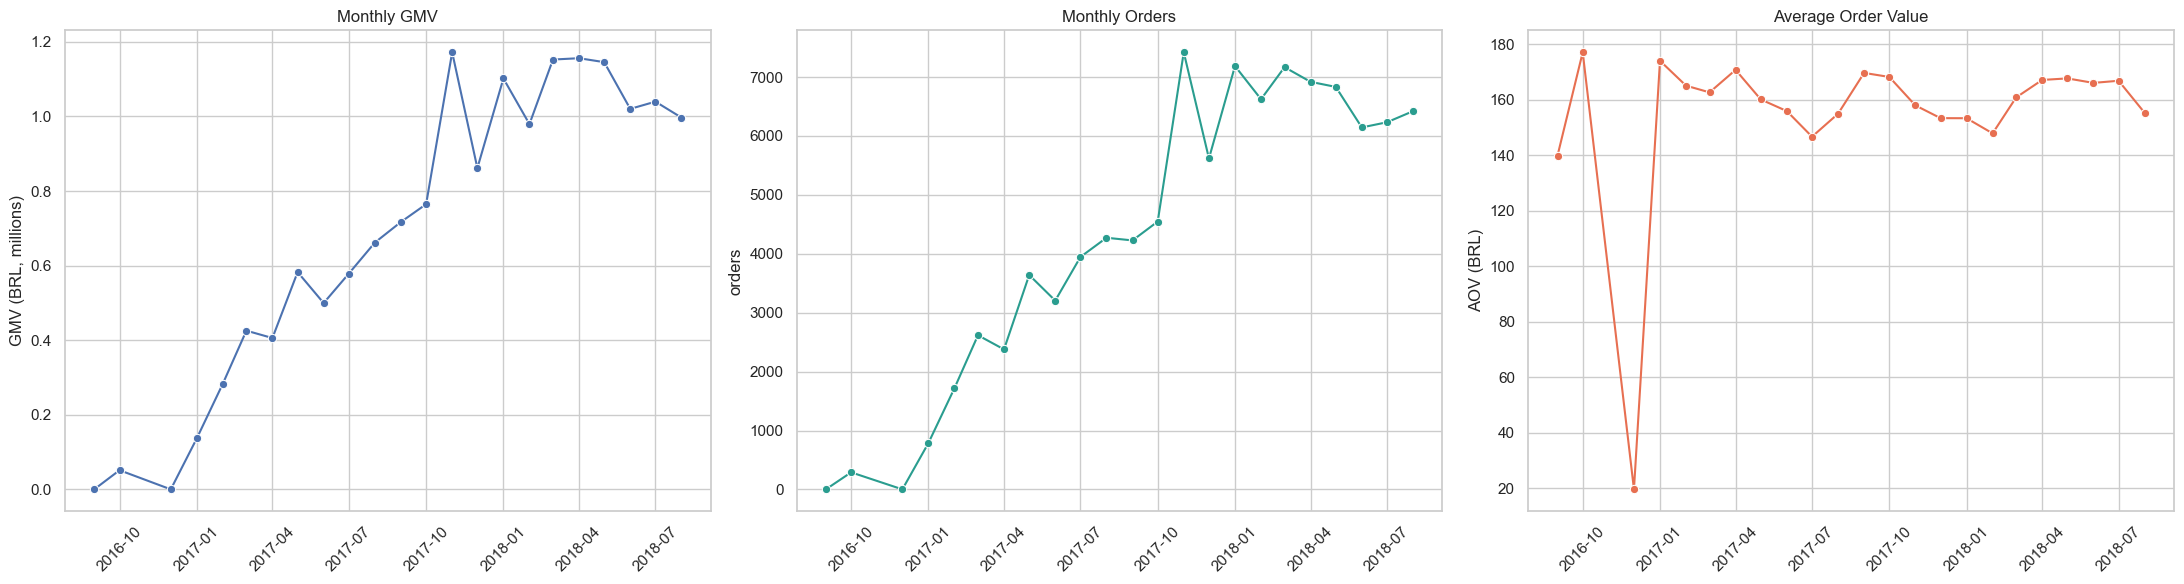

In [32]:
from matplotlib.ticker import FuncFormatter

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.lineplot(
    data=monthly_metrics_full,
    x="purchase_month",
    y="gmv",
    marker="o",
    ax=axes[0],
)

axes[0].set_title("Monthly GMV")
axes[0].set_xlabel("")
axes[0].set_ylabel("GMV (BRL, millions)")
axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x / 1_000_000:.1f}")
)
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=monthly_metrics_full,
    x="purchase_month",
    y="orders",
    marker="o",
    color="#2a9d8f",
    ax=axes[1],
)

axes[1].set_title("Monthly Orders")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=monthly_metrics_full,
    x="purchase_month",
    y="aov",
    marker="o",
    color="#e76f51",
    ax=axes[2],
)

axes[2].set_title("Average Order Value")
axes[2].set_xlabel("")
axes[2].set_ylabel("AOV (BRL)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.savefig(
    "images/monthly_gmv.png",
    bbox_inches="tight",
    dpi=300,
)

plt.tight_layout()
plt.show()

peak_month = monthly_metrics_full.loc[
    monthly_metrics_full["gmv"].idxmax()
]

start_month = monthly_metrics_full.iloc[0]
end_month = monthly_metrics_full.iloc[-1]

gmv_growth = (
    end_month["gmv"] / start_month["gmv"] - 1
)

> Interpretation
> * Monthly GMV peaks around late 2017, suggesting strong marketplace seasonality and accelerated commercial activity during that period.
> * GMV grows more than 35x throughout the observed timeframe, reflecting rapid marketplace expansion and increasing platform adoption.
> * Order volume follows a growth trajectory similar to GMV, reinforcing the idea that marketplace expansion is driven primarily by transaction scale.
> * Average order value remains relatively stable near BRL 160, suggesting that growth is driven more by increasing order volume than by larger customer baskets.

## 4.2 Customer Acquisition vs Repeat Behavior

After reviewing marketplace growth, the next step is understanding whether that growth is supported by repeat purchasing behavior.

This analysis compares new customer acquisition with returning customer activity over time and measures the share of monthly orders coming from repeat purchases.

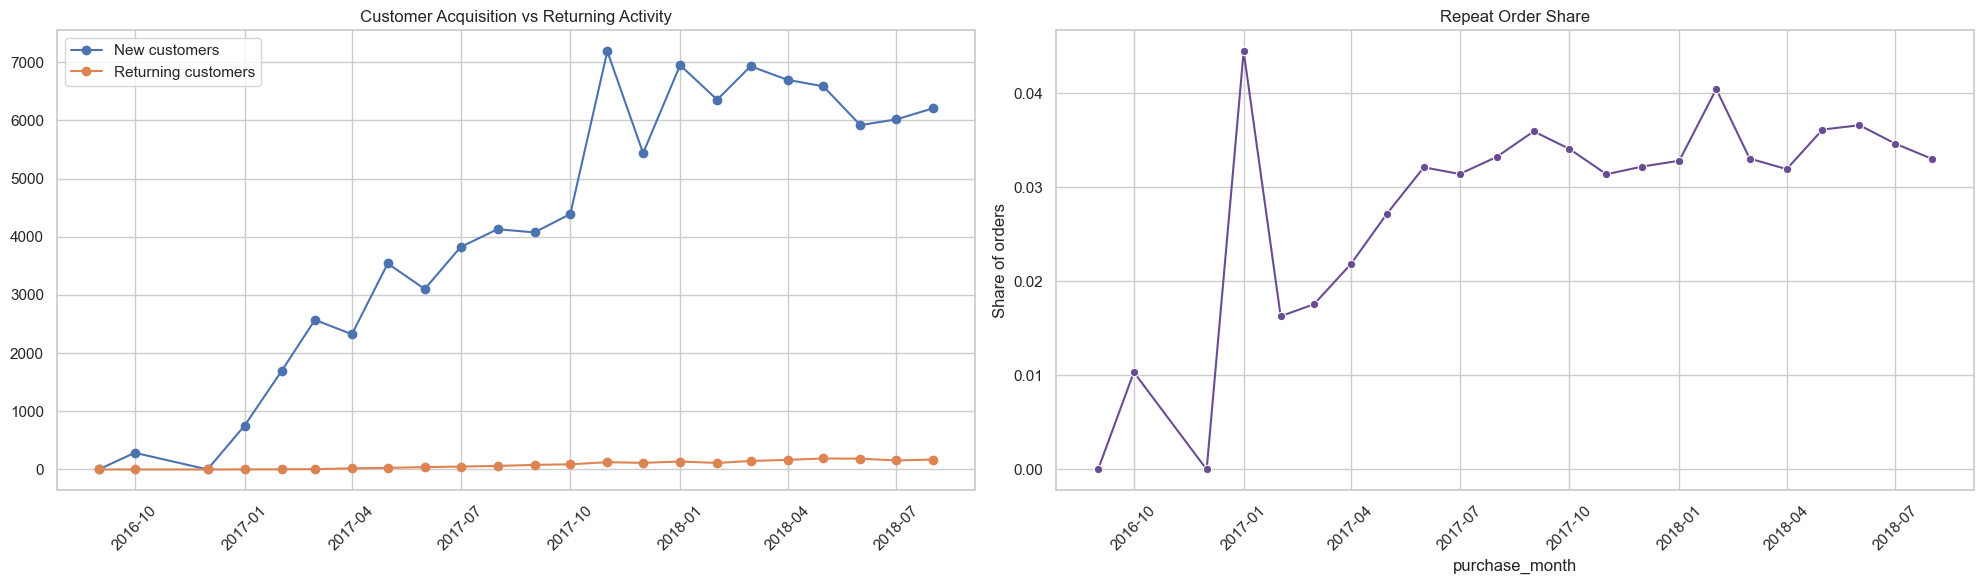

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

monthly_customer_mix_plot = monthly_customer_mix[
    monthly_customer_mix["purchase_month"]
    < monthly_customer_mix["purchase_month"].max()
].copy()

axes[0].plot(
    monthly_customer_mix_plot["purchase_month"],
    monthly_customer_mix_plot["new_customers"],
    marker="o",
    label="New customers",
)

axes[0].plot(
    monthly_customer_mix_plot["purchase_month"],
    monthly_customer_mix_plot["returning_customer_proxy"],
    marker="o",
    label="Returning customers",
)

axes[0].set_title("Customer Acquisition vs Returning Activity")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

sns.lineplot(
    data=monthly_customer_mix_plot,
    x="purchase_month",
    y="repeat_order_share",
    marker="o",
    color="#6a4c93",
    ax=axes[1],
)

axes[1].set_title("Repeat Order Share")
axes[1].set_ylabel("Share of orders")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

repeat_rate = customer_level["repeat_customer"].mean()

avg_repeat_share = (
    monthly_customer_mix_plot["repeat_order_share"]
    .mean()
)

> Interpretation
> * Marketplace growth is primarily driven by continuous customer acquisition rather than by a large returning-customer base.
> * New customers represent the majority of monthly purchasing activity throughout most of the observed period.
> * Repeat order share remains relatively stable over time, suggesting that marketplace expansion came mostly from scaling demand volume instead of materially changing customer purchasing behavior.
> * This dynamic indicates that acquisition efficiency likely played a central role in marketplace growth during the analyzed period.

## 4.3 Category Scale, Concentration, and Satisfaction

Marketplace growth is not distributed evenly across product categories.

This analysis investigates which categories drive the largest share of GMV and whether operational complexity, freight intensity, and customer satisfaction vary across high-scale marketplace verticals.

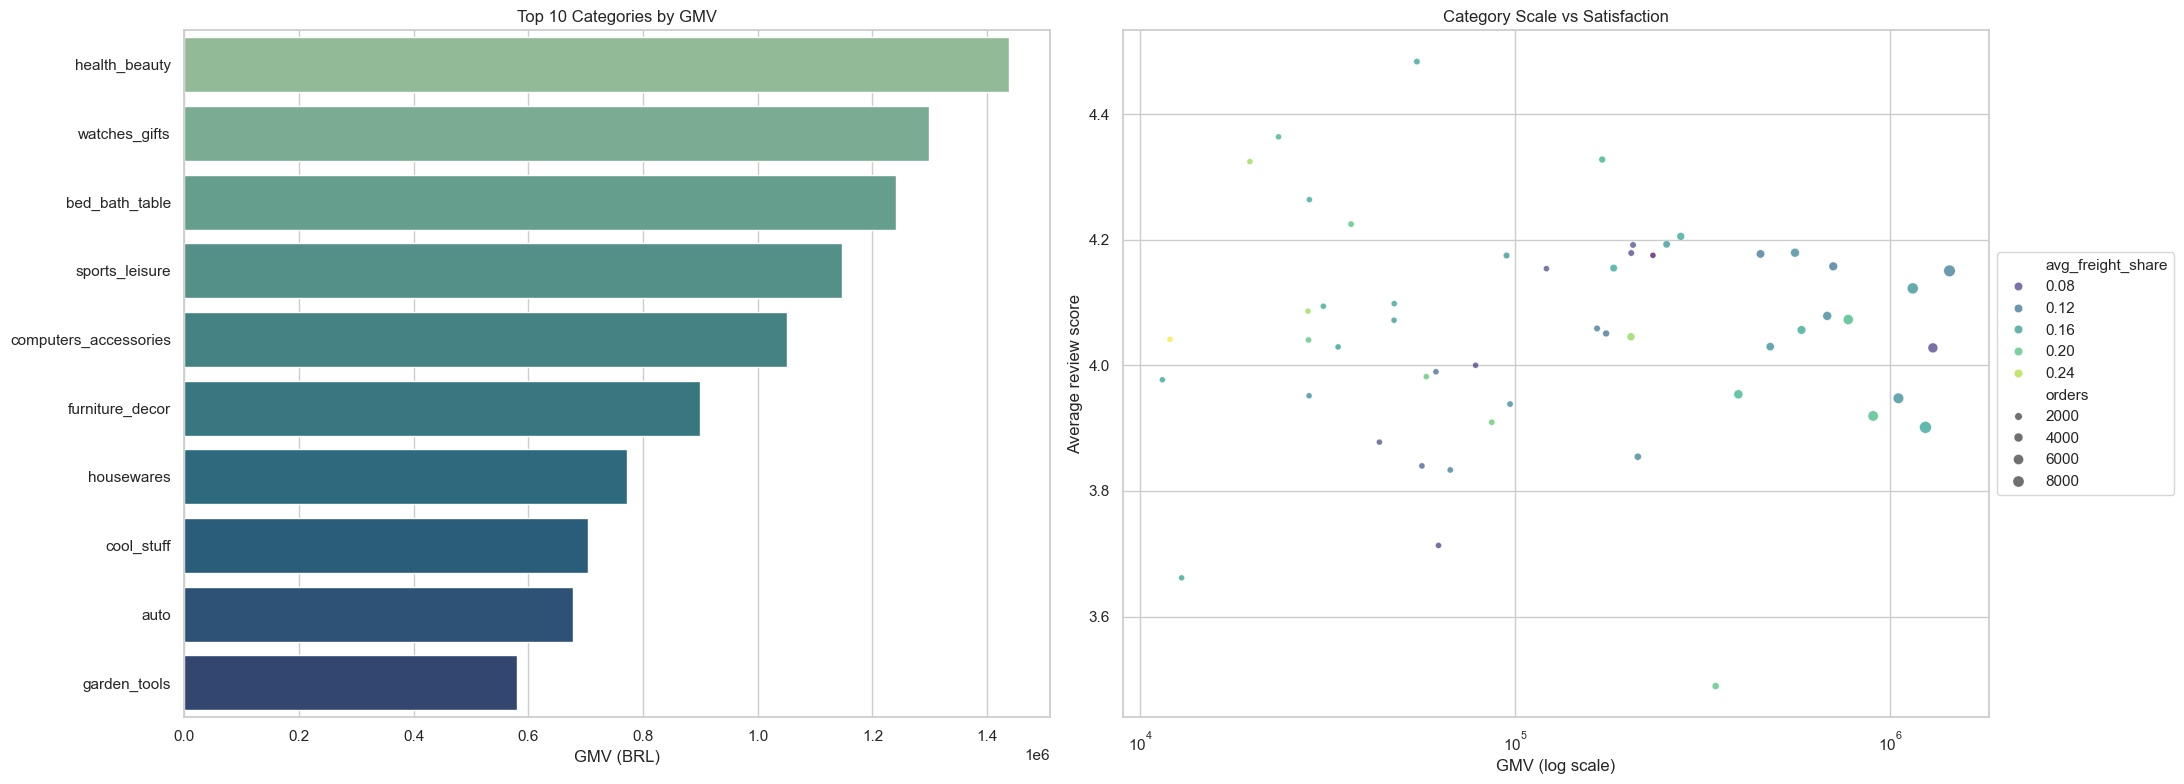

,product_category_name_english,gmv,orders,avg_review,avg_freight_share
0,health_beauty,"1,437,665.78",8800,4.15,0.13
1,watches_gifts,"1,298,292.47",5604,4.03,0.08
2,bed_bath_table,"1,240,386.13",9399,3.90,0.16
3,sports_leisure,"1,147,244.63",7673,4.12,0.15
4,computers_accessories,"1,050,941.58",6654,3.95,0.14
5,furniture_decor,"899,626.04",6425,3.92,0.19
6,housewares,"772,035.14",5847,4.07,0.19
7,cool_stuff,"704,086.24",3616,4.16,0.12
8,auto,"678,606.64",3872,4.08,0.14
9,garden_tools,"579,525.20",3505,4.06,0.17


In [16]:
top_categories = category_summary.head(10).copy()

review_cutoff = (
    category_summary["avg_review"].median()
)

gmv_cutoff = (
    category_summary["gmv"].quantile(0.75)
)

fix_categories = category_summary[
    (category_summary["gmv"] >= gmv_cutoff)
    & (category_summary["avg_review"] < review_cutoff)
].sort_values("gmv", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.barplot(
    data=top_categories,
    y="product_category_name_english",
    x="gmv",
    palette="crest",
    ax=axes[0],
)

axes[0].set_title("Top 10 Categories by GMV")
axes[0].set_xlabel("GMV (BRL)")
axes[0].set_ylabel("")

sns.scatterplot(
    data=category_summary.query("orders >= 100"),
    x="gmv",
    y="avg_review",
    size="orders",
    hue="avg_freight_share",
    palette="viridis",
    alpha=0.7,
    ax=axes[1],
)

axes[1].set_xscale("log")

axes[1].set_title("Category Scale vs Satisfaction")
axes[1].set_xlabel("GMV (log scale)")
axes[1].set_ylabel("Average review score")

axes[1].legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
)

plt.tight_layout()
plt.show()

display(
    category_summary[
        [
            "product_category_name_english",
            "gmv",
            "orders",
            "avg_review",
            "avg_freight_share",
        ]
    ]
    .head(10)
    .reset_index(drop=True)
    .round(2)
)

> Interpretation
> * The **health_beauty** category leads marketplace GMV, but GMV remains diversified across multiple product verticals rather than concentrated in a single category.
> * Large-scale categories such as **bed_bath_table**, **computers_accessories**, and **furniture_decor** combine high commercial relevance with relatively weaker customer satisfaction indicators.
> * Freight-intensive categories tend to show lower review scores, suggesting that logistics complexity plays an important role in customer experience deterioration.
> * The relationship between scale, freight intensity, and review quality suggests that operational execution becomes increasingly important as category volume grows.

## 4.4 Seller Concentration and Operational Quality

Marketplace growth also depends on the distribution and operational quality of sellers within the ecosystem.

This analysis evaluates seller concentration, marketplace dependency on top-performing merchants, and the relationship between seller scale and customer satisfaction.

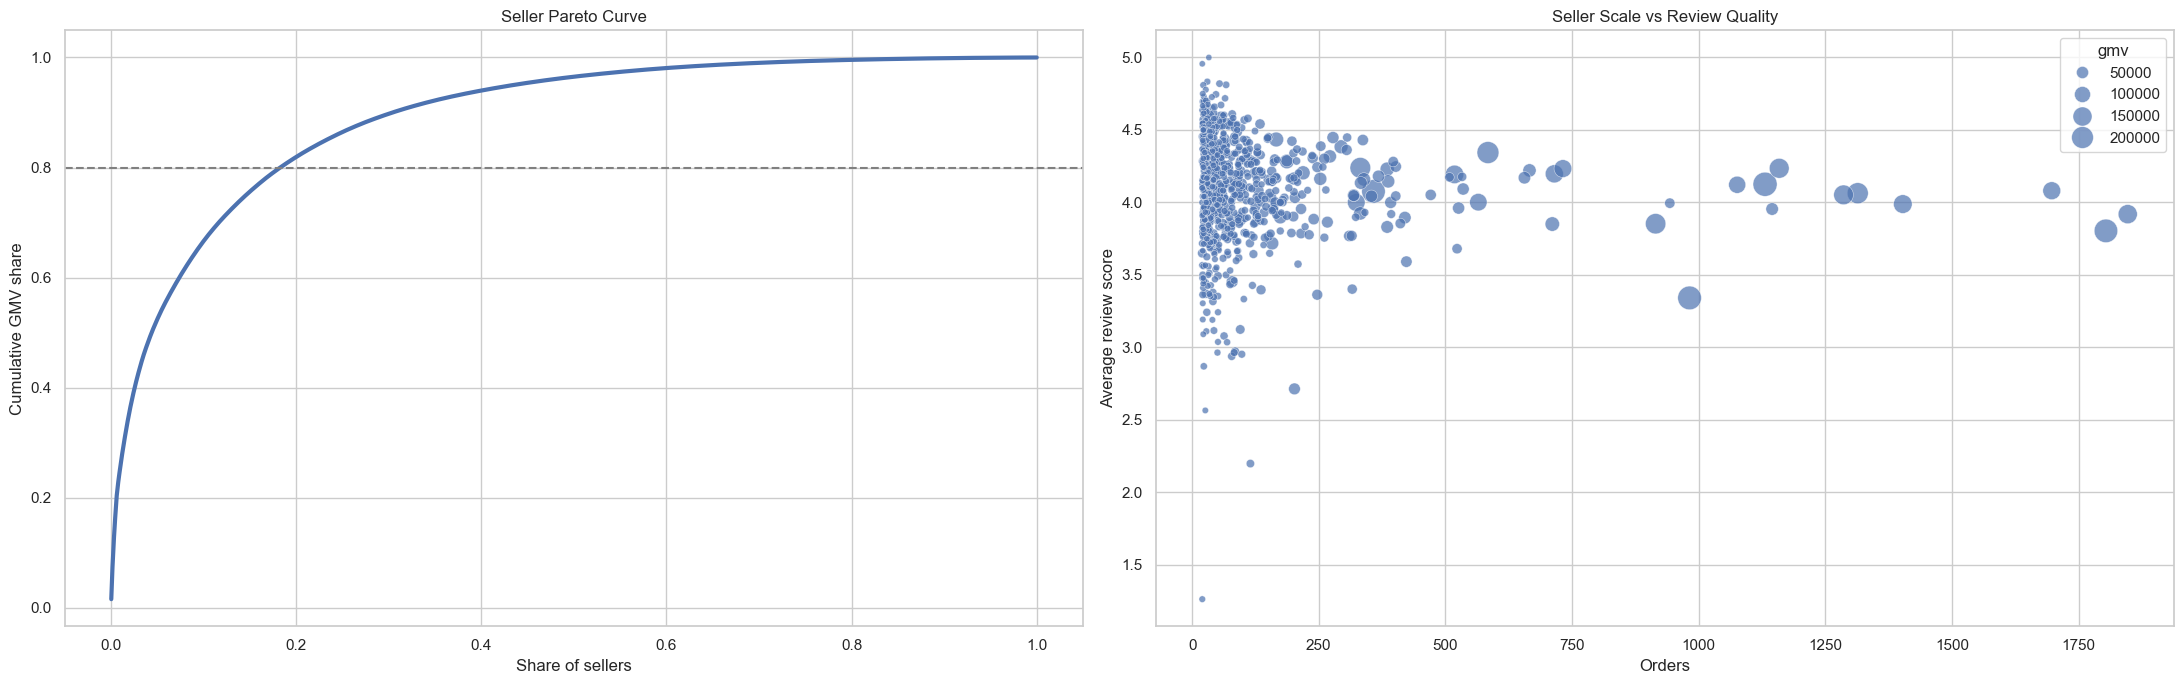

,seller_id,gmv,orders,avg_review,late_delivery_rate
0,1ca7077d890b907f89be8c954a02686a,"15,001.43",115,2.20,0.14
1,2eb70248d66e0e3ef83659f71b244378,"45,860.10",202,2.71,0.11
2,b2479f944e1b90cf8a5de1bbfde284d6,"6,943.54",102,3.33,0.12
3,7c67e1448b00f6e969d365cea6b010ab,"239,536.44",982,3.34,0.09
4,88460e8ebdecbfecb5f9601833981930,"36,377.40",247,3.36,0.16


In [40]:
seller_top10_share = (
    seller_summary.head(10)["gmv"].sum()
    / seller_summary["gmv"].sum()
)

seller_top50_share = (
    seller_summary.head(50)["gmv"].sum()
    / seller_summary["gmv"].sum()
)

risky_sellers = (
    seller_summary[seller_summary["orders"] >= 100]
    .sort_values(["avg_review", "gmv"], ascending=[True, False])
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(22, 7))

seller_curve = seller_summary.reset_index(drop=True).copy()

seller_curve["seller_percentile"] = (
    (seller_curve.index + 1)
    / len(seller_curve)
)

axes[0].plot(
    seller_curve["seller_percentile"],
    seller_curve["cumulative_gmv_share"],
    linewidth=3,
)

axes[0].axhline(
    0.8,
    linestyle="--",
    color="gray",
)

axes[0].set_title("Seller Pareto Curve")
axes[0].set_xlabel("Share of sellers")
axes[0].set_ylabel("Cumulative GMV share")

sns.scatterplot(
    data=seller_summary[
        seller_summary["orders"] >= 20
    ],
    x="orders",
    y="avg_review",
    size="gmv",
    sizes=(20, 300),
    alpha=0.7,
    ax=axes[1],
)

axes[1].set_title("Seller Scale vs Review Quality")
axes[1].set_xlabel("Orders")
axes[1].set_ylabel("Average review score")

plt.tight_layout()

plt.savefig(
    "images/pareto_curves.png",
    bbox_inches="tight",
    dpi=300,
)

plt.tight_layout()
plt.show()

display(
    risky_sellers[
        [
            "seller_id",
            "gmv",
            "orders",
            "avg_review",
            "late_delivery_rate",
        ]
    ]
    .head(5)
    .reset_index(drop=True)
    .round(2)
)

> Interpretation
> * The marketplace shows meaningful seller concentration, with the top 10 sellers generating about 12.9% of total GMV and the top 50 accounting for 32.4%.
> * Some large-scale sellers combine strong commercial relevance with weaker customer satisfaction indicators, creating operational quality management challenges.
> * The seller quality distribution suggests that marketplace growth alone is not sufficient if operational standards deteriorate among strategically important merchants.
> * Marketplace operations should prioritize retaining high-performing strategic sellers while intervening quickly when large sellers generate avoidable customer experience risk.

## 4.5 Logistics Performance and Customer Satisfaction

Customer experience in marketplaces is strongly influenced by operational execution and fulfillment quality.

This analysis investigates how review scores relate to delivery timeliness and shipping distance, helping identify whether logistics friction contributes meaningfully to customer satisfaction deterioration.

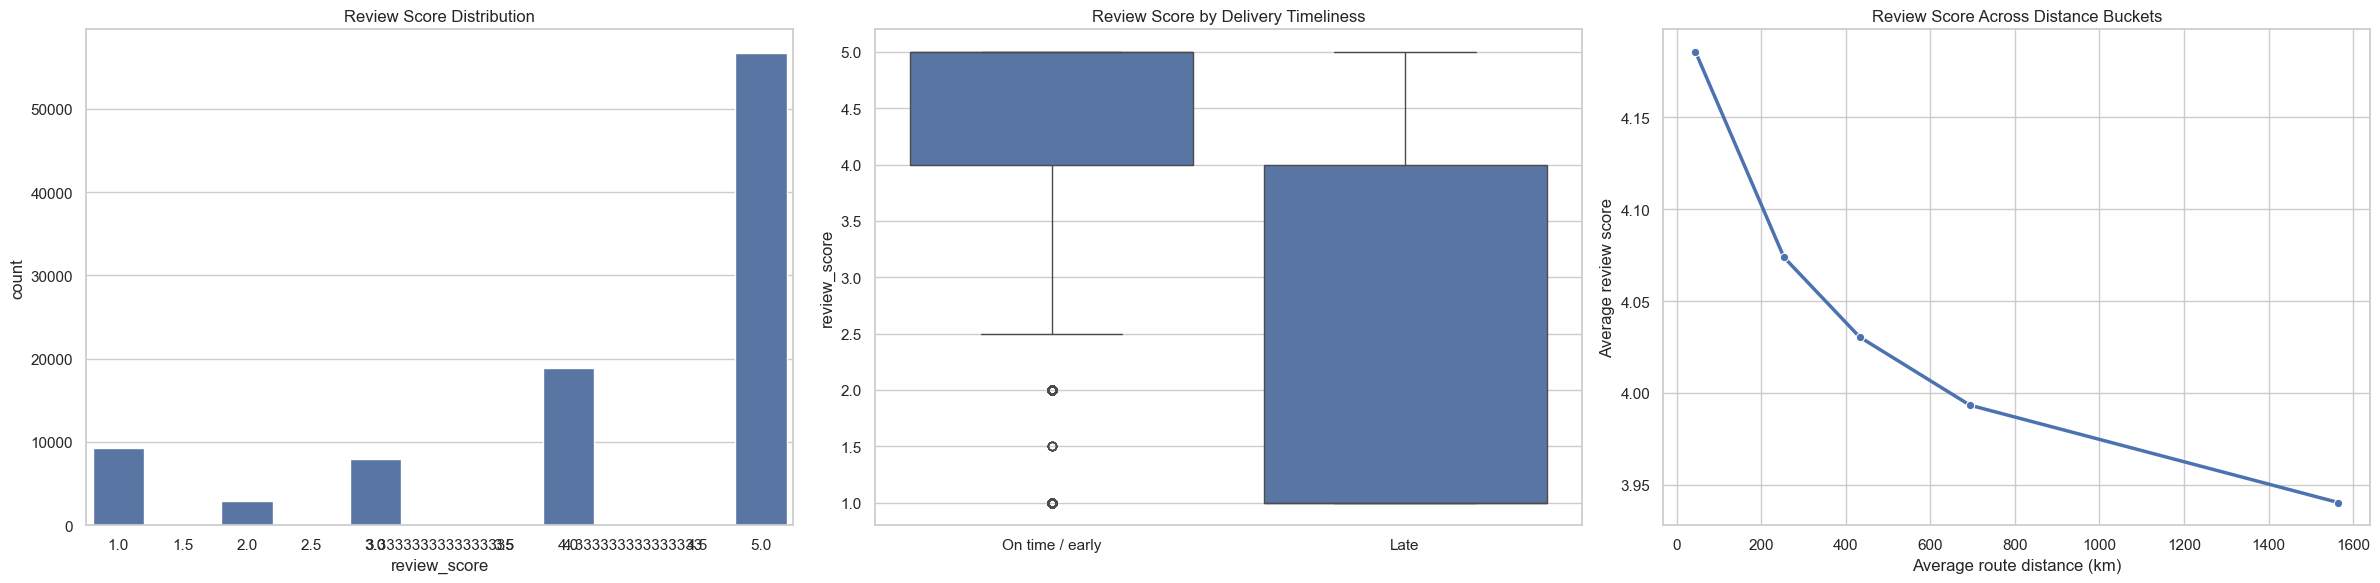

In [18]:
review_by_lateness = delivered_orders.assign(
    delivery_status=np.where(
        delivered_orders["is_late_delivery"] == 1,
        "Late",
        "On time / early",
    )
)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

sns.countplot(
    data=delivered_orders,
    x="review_score",
    ax=axes[0],
)

axes[0].set_title("Review Score Distribution")

sns.boxplot(
    data=review_by_lateness,
    x="delivery_status",
    y="review_score",
    ax=axes[1],
)

axes[1].set_title("Review Score by Delivery Timeliness")
axes[1].set_xlabel("")

sns.lineplot(
    data=distance_summary,
    x="avg_distance_km",
    y="avg_review",
    marker="o",
    linewidth=2.5,
    ax=axes[2],
)

axes[2].set_title("Review Score Across Distance Buckets")
axes[2].set_xlabel("Average route distance (km)")
axes[2].set_ylabel("Average review score")

plt.tight_layout()
plt.show()

review_on_time = review_by_lateness.loc[
    review_by_lateness["delivery_status"] == "On time / early",
    "review_score",
].mean()

review_late = review_by_lateness.loc[
    review_by_lateness["delivery_status"] == "Late",
    "review_score",
].mean()

> Interpretation
> * Customer satisfaction is heavily concentrated in high review scores, but late delivery is a major exception: average review drops from 4.29 to 2.27 when orders arrive late.
> * Longer shipping distances are also associated with gradually lower review scores, reinforcing that logistics performance directly affects customer experience quality.
> * Delivery reliability appears to be a strategically important operational KPI, since reducing delays likely improves customer trust, satisfaction, and repeat purchase probability.

## 4.6 Regional GMV and Route Economics

Marketplace performance also depends on where demand is concentrated and how orders move across regions.

This analysis compares GMV concentration by customer state and evaluates whether cross-state routes create additional logistics pressure through higher freight costs and different customer experience patterns.

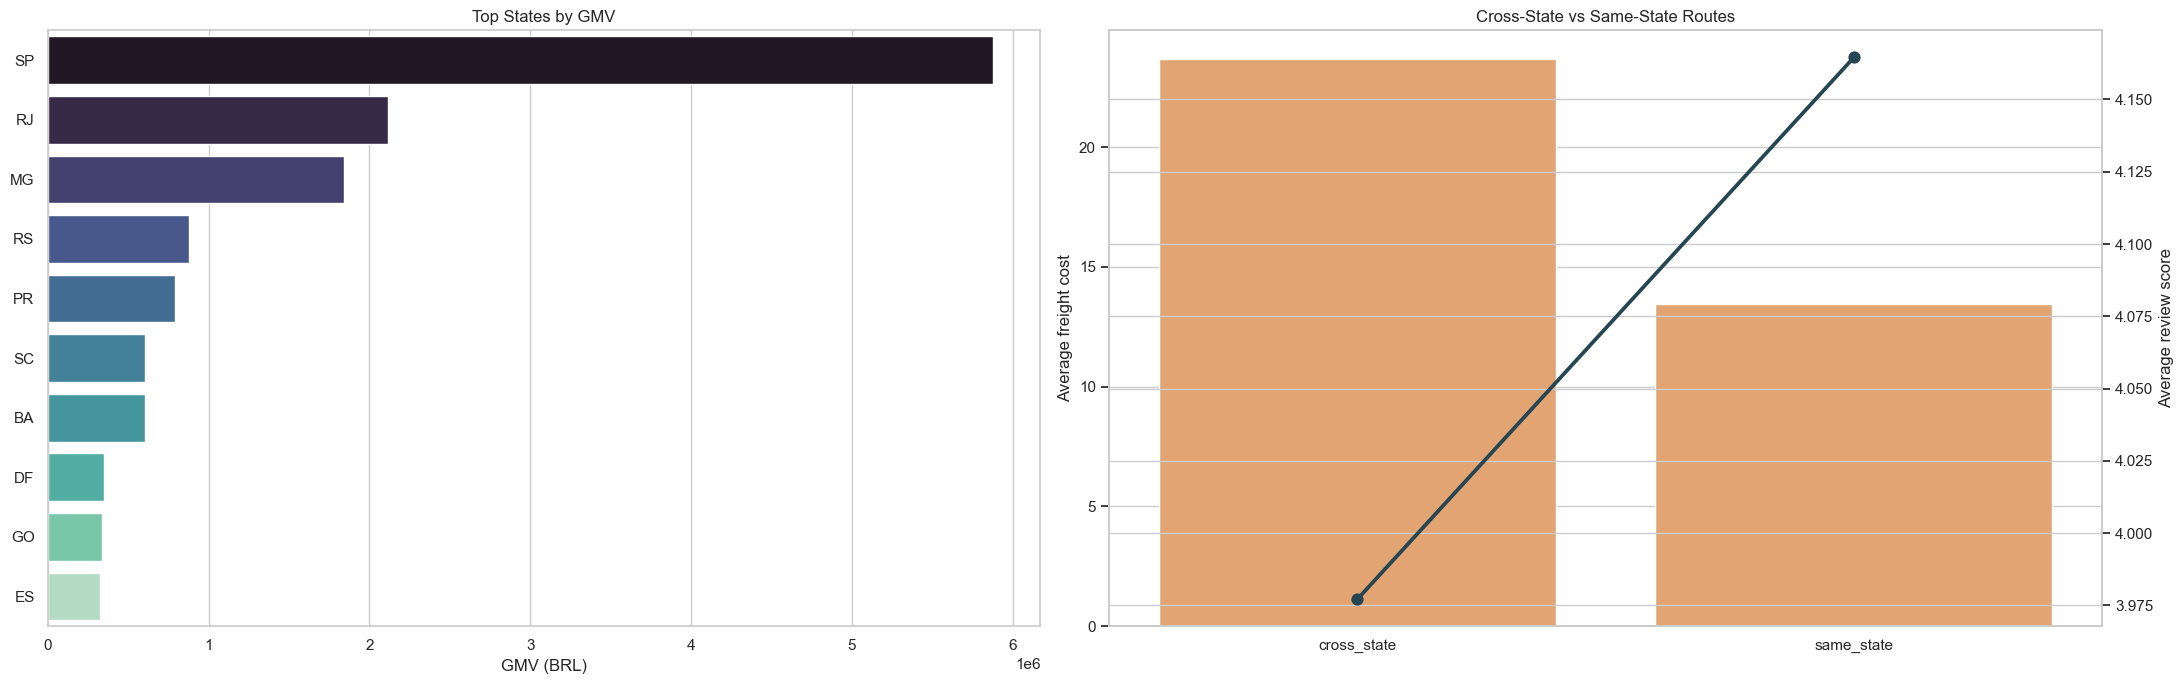

In [19]:
top_states = state_summary.head(10).copy()

fig, axes = plt.subplots(1, 2, figsize=(22, 7))

sns.barplot(
    data=top_states,
    x="gmv",
    y="customer_state",
    palette="mako",
    ax=axes[0],
)

axes[0].set_title("Top States by GMV")
axes[0].set_xlabel("GMV (BRL)")
axes[0].set_ylabel("")

sns.barplot(
    data=route_summary,
    x="route_type",
    y="avg_freight",
    color="#f4a261",
    ax=axes[1],
)

axes[1].set_ylabel("Average freight cost")
axes[1].set_xlabel("")

ax2 = axes[1].twinx()

sns.pointplot(
    data=route_summary,
    x="route_type",
    y="avg_review",
    color="#264653",
    ax=ax2,
)

ax2.set_ylabel("Average review score")

axes[1].set_title("Cross-State vs Same-State Routes")

plt.tight_layout()
plt.show()

top_state = top_states.iloc[0]

cross_state_row = route_summary.loc[
    route_summary["route_type"] == "cross_state"
].iloc[0]

> Interpretation
> * **SP** is the primary GMV driver of the marketplace, reflecting the strong regional concentration of marketplace demand and commercial activity.
> * Cross-state deliveries account for 69.8% of marketplace GMV, while also carrying materially higher freight costs than same-state routes.
> * Although the marketplace operates on a national scale, the logistics economics suggest that improving regional inventory allocation and seller density could strengthen both margins and customer experience.

## 4.7 Cohort Retention Over Time

To better understand customer retention, this analysis tracks monthly cohorts based on each customer's first purchase month.

The goal is to evaluate whether customers continue purchasing after their first order and how quickly retention decays over time.

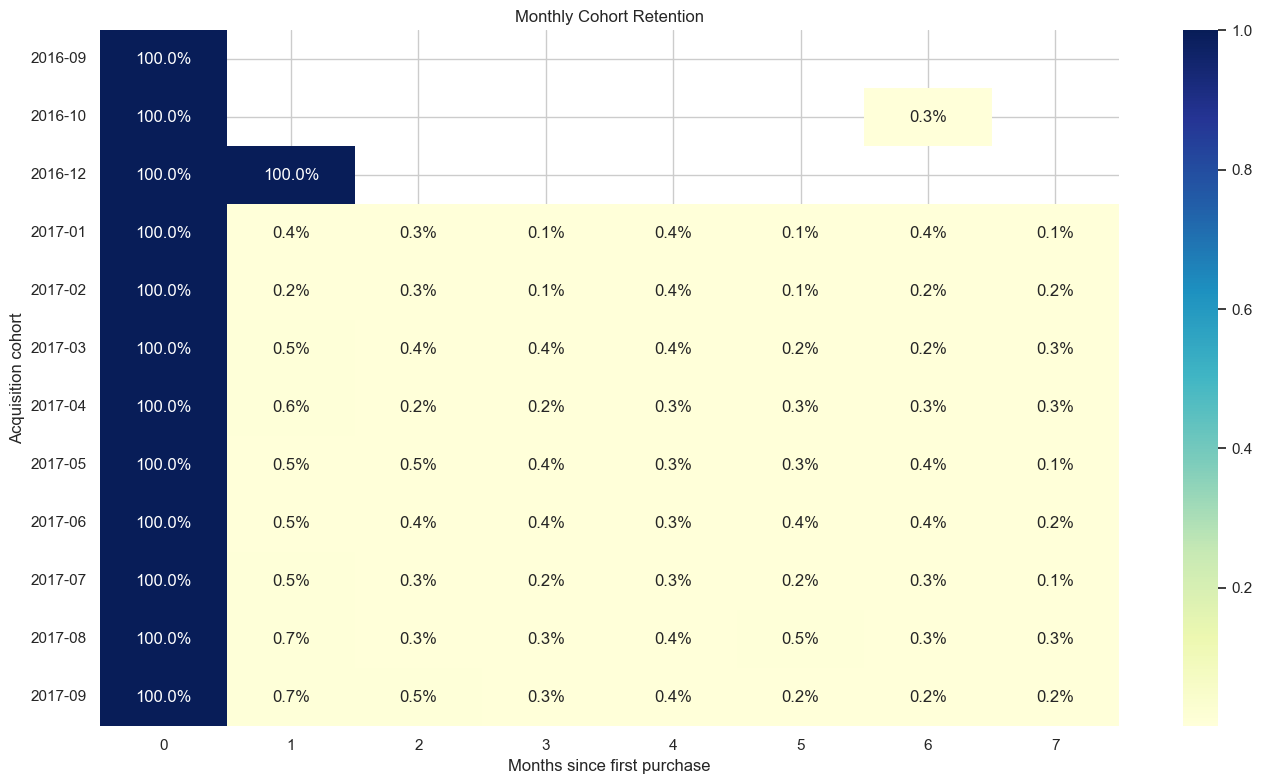

In [33]:
cohort_heatmap = cohort_matrix.copy()

cohort_heatmap.index = (
    cohort_heatmap.index.astype(str)
)

cohort_heatmap = cohort_heatmap.iloc[:12, :8]

plt.figure(figsize=(14, 8))

sns.heatmap(
    cohort_heatmap,
    annot=True,
    fmt=".1%",
    cmap="YlGnBu",
)

plt.title("Monthly Cohort Retention")
plt.xlabel("Months since first purchase")
plt.ylabel("Acquisition cohort")

plt.tight_layout()

plt.savefig(
    "images/cohort_retention.png",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

avg_retention_m1 = cohort_matrix[1].mean()
avg_retention_m3 = cohort_matrix[3].mean()

> Interpretation
> * Most customer cohorts exhibit a steep decline in activity immediately after the first purchase, with retention dropping sharply after month 1.
> * Average month-1 retention is approximately 5.2%, indicating that only a small fraction of acquired customers return shortly after acquisition.
> * By month 3, retention falls close to zero for most cohorts, suggesting limited long-term purchasing continuity across the customer base.
> * The similarity across cohorts indicates that this pattern is structural rather than isolated to a specific acquisition period or seasonal event.

# 5. Customer Lifetime Value (LTV)

One of the most interesting patterns in this marketplace is how difficult it is to create repeat purchasing behavior. Most customers purchase only once, which means long-term marketplace growth depends less on acquiring traffic and more on creating a reason for customers to come back.

The analysis starts with a realized historical LTV view, measuring how much GMV each customer actually generated during the observed period. This creates a simple but reliable baseline before moving into predictive approaches.

To extend the analysis further, the notebook also applies probabilistic lifetime modeling using BG/NBD and Gamma-Gamma models from the **lifetimes** package. Rather than trying to predict the exact future value of every customer, the objective is to identify which customers are more likely to purchase again and which segments have stronger long-term value potential.

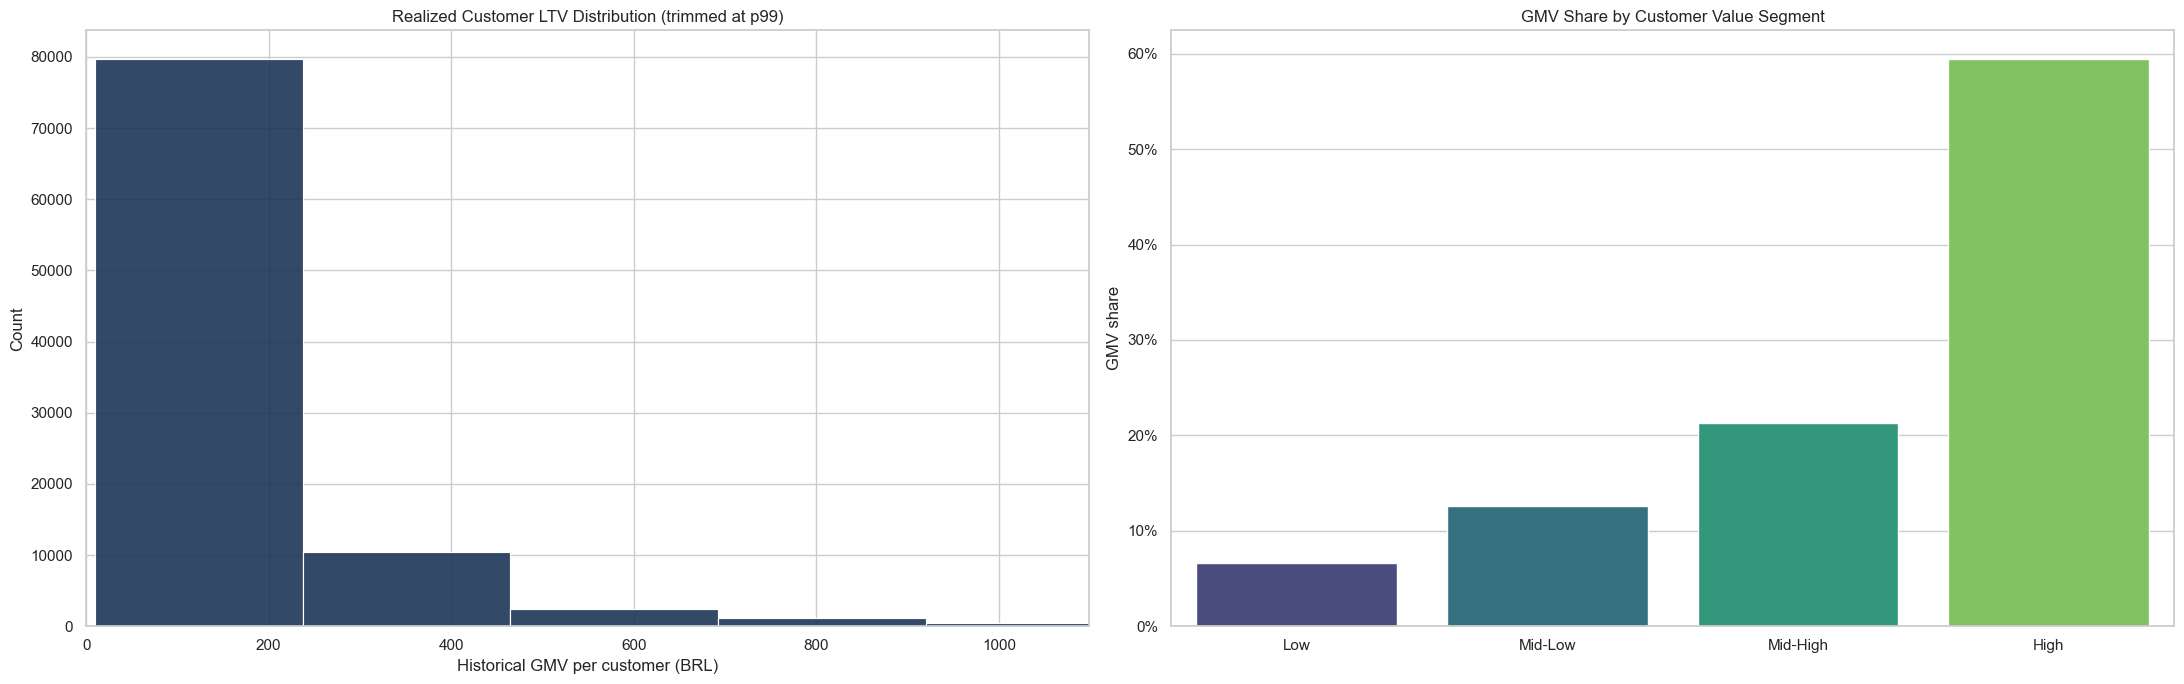

,value_segment,customers,gmv,avg_orders,avg_review,avg_recency_days,gmv_share
0,Low,23771,"1,037,709.98",1.00,4.20,244.88,0.07
1,Mid-Low,23726,"1,985,657.05",1.01,4.14,245.89,0.13
2,Mid-High,23741,"3,353,465.32",1.03,4.12,238.47,0.21
3,High,23745,"9,358,694.68",1.09,4.00,240.49,0.59


In [39]:
from matplotlib.ticker import PercentFormatter

ltv_segment_summary = (
    customer_level.groupby(
        "value_segment",
        observed=False,
        as_index=False,
    )
    .agg(
        customers=("customer_unique_id", "nunique"),
        gmv=("realized_ltv", "sum"),
        avg_orders=("total_orders", "mean"),
        avg_review=("avg_review_score", "mean"),
        avg_recency_days=("recency_days", "mean"),
    )
)

ltv_segment_summary["gmv_share"] = (
    ltv_segment_summary["gmv"]
    / ltv_segment_summary["gmv"].sum()
)

fig, axes = plt.subplots(1, 2, figsize=(22, 7))

sns.histplot(
    customer_level["realized_ltv"],
    bins=60,
    alpha=0.9,
    color="#1d3557",
    ax=axes[0],
)

axes[0].set_xlim(
    0,
    customer_level["realized_ltv"].quantile(0.99),
)

axes[0].set_title(
    "Realized Customer LTV Distribution (trimmed at p99)"
)

axes[0].set_xlabel(
    "Historical GMV per customer (BRL)"
)

sns.barplot(
    data=ltv_segment_summary,
    x="value_segment",
    y="gmv_share",
    palette="viridis",
    ax=axes[1],
)

axes[1].set_title("GMV Share by Customer Value Segment")
axes[1].set_xlabel("")
axes[1].set_ylabel("GMV share")
axes[1].yaxis.set_major_formatter(
    PercentFormatter(1)
)

plt.tight_layout()

plt.savefig(
    "images/ltv_distribution.png",
    bbox_inches="tight",
    dpi=300,
)

plt.tight_layout()
plt.show()

display(
    ltv_segment_summary
    .round(2)
)

median_ltv = (
    customer_level["realized_ltv"].median()
)

p90_ltv = (
    customer_level["realized_ltv"].quantile(0.90)
)

repeat_rate = (
    customer_level["repeat_customer"].mean()
)

high_segment_share = ltv_segment_summary.loc[
    ltv_segment_summary["value_segment"] == "High",
    "gmv_share",
].iat[0]

> Interpretation
> * Historical customer LTV is strongly right-skewed: the median customer generates about BRL 108 in GMV, while the p90 customer contributes roughly BRL 319.
> * Customer value is meaningfully concentrated, with the highest-value segment accounting for approximately 59.5% of total marketplace GMV.
> * Average order counts remain relatively similar across segments, suggesting that differences in customer value are driven more by basket economics and cumulative purchasing behavior than by extremely high purchase frequency alone.
> * This concentration pattern supports the case for differentiated retention, CRM, and personalization strategies targeting strategically valuable customer groups.

## 5.1 Probabilistic Customer Lifetime Modeling

To extend the LTV analysis beyond historical customer value, this section applies probabilistic lifetime modeling using BG/NBD and Gamma-Gamma models.

Rather than forecasting exact future marketplace GMV for individual customers, the objective is to estimate relative long-term value potential and future purchasing propensity across the customer base.

In [22]:
from lifetimes import (
    BetaGeoFitter,
    GammaGammaFitter,
)

from lifetimes.utils import (
    summary_data_from_transaction_data,
)

ltv_transactions = delivered_orders[
    [
        "customer_unique_id",
        "order_purchase_timestamp",
        "order_gmv",
    ]
].dropna()

lifetimes_summary = (
    summary_data_from_transaction_data(
        transactions=ltv_transactions,
        customer_id_col="customer_unique_id",
        datetime_col="order_purchase_timestamp",
        monetary_value_col="order_gmv",
        observation_period_end=ltv_transactions[
            "order_purchase_timestamp"
        ].max(),
        freq="D",
    )
)

bgf = BetaGeoFitter(
    penalizer_coef=0.01
)

bgf.fit(
    lifetimes_summary["frequency"],
    lifetimes_summary["recency"],
    lifetimes_summary["T"],
)

ggf_input = lifetimes_summary[
    lifetimes_summary["monetary_value"] > 0
].copy()

ggf = GammaGammaFitter(
    penalizer_coef=0.01
)

ggf.fit(
    ggf_input["frequency"],
    ggf_input["monetary_value"],
)

ggf_input["predicted_6m_purchases"] = (
    bgf.conditional_expected_number_of_purchases_up_to_time(
        180,
        ggf_input["frequency"],
        ggf_input["recency"],
        ggf_input["T"],
    )
)

ggf_input["predicted_6m_ltv"] = (
    ggf.customer_lifetime_value(
        bgf,
        ggf_input["frequency"],
        ggf_input["recency"],
        ggf_input["T"],
        ggf_input["monetary_value"],
        time=6,
        freq="D",
        discount_rate=0.01,
    )
)

display(
    ggf_input[
        [
            "frequency",
            "monetary_value",
            "predicted_6m_purchases",
            "predicted_6m_ltv",
        ]
    ].describe()
)

,frequency,monetary_value,predicted_6m_purchases,predicted_6m_ltv
count,"2,015.00","2,015.00","2,015.00","2,015.00"
mean,1.11,151.11,0.11,17.73
std,0.51,160.32,0.26,50.16
min,1.00,11.56,0.00,0.14
25%,1.00,62.69,0.02,2.34
50%,1.00,108.30,0.04,5.07
75%,1.00,179.22,0.07,11.45
max,14.00,"2,405.28",4.84,773.70


> Interpretation
> * The probabilistic LTV models estimate expected future purchase activity and customer value based on historical transaction behavior.
> * Predicted future purchasing activity remains relatively low across most customers, reinforcing the marketplace's weak natural retention dynamics.
> * The strong dispersion in predicted LTV suggests that a relatively small subset of customers still carries disproportionately higher long-term value potential.
> * Given the low repeat purchase frequency observed throughout the marketplace, these models are likely more useful for customer prioritization and relative value estimation than for precise long-term marketplace value forecasting.

# 6. Experimentation: Simulated A/B Test

The original marketplace data is observational, meaning there is no true historical randomized experiment available. To explore how retention initiatives could affect marketplace performance, this section simulates a realistic customer-level A/B test.

The experiment evaluates whether offering a 10% discount on a future purchase could increase customer conversion and improve downstream marketplace value generation.

The simulation follows a simplified experimental structure:

- **Unit of randomization:** customer
- **Population:** customers with a first observed purchase before a fixed cutoff
- **Treatment:** a 10% discount incentive
- **Primary metric:** conversion within 90 days
- **Secondary metric:** GMV per user after discount effects

Although the experiment is simulated rather than causal, it provides a useful framework for thinking about retention economics, promotional efficiency, and marketplace growth strategy under transparent assumptions.

## 6.1 Experiment Design and Eligible Population

The first step defines the simulated experiment structure and selects the customers who would be eligible for the retention campaign.

The experiment uses customers with a first observed purchase before a fixed cutoff date, then tracks whether they place another order within the following 90-day window.

In [23]:
experiment_cutoff = pd.Timestamp("2018-03-01")
experiment_window_days = 90

first_orders = (
    completed_orders
    .sort_values("order_purchase_timestamp")
    .groupby("customer_unique_id", as_index=False)
    .first()
)

eligible_customers = first_orders[
    first_orders["order_purchase_timestamp"] < experiment_cutoff
].copy()

future_orders = completed_orders[
    (completed_orders["order_purchase_timestamp"] >= experiment_cutoff)
    & (
        completed_orders["order_purchase_timestamp"]
        < experiment_cutoff + pd.Timedelta(days=experiment_window_days)
    )
].copy()

future_customer_outcomes = (
    future_orders.groupby("customer_unique_id", as_index=False)
    .agg(
        future_orders=("order_id", "nunique"),
        future_gmv=("order_gmv", "sum"),
    )
)

experiment = eligible_customers.merge(
    future_customer_outcomes,
    on="customer_unique_id",
    how="left",
).fillna(
    {
        "future_orders": 0,
        "future_gmv": 0,
    }
)

experiment["baseline_conversion"] = (
    experiment["future_orders"] > 0
).astype(int)

display(
    experiment[
        [
            "customer_unique_id",
            "order_purchase_timestamp",
            "order_gmv",
            "future_orders",
            "future_gmv",
            "baseline_conversion",
        ]
    ]
    .head()
    .round(2)
)

,customer_unique_id,order_purchase_timestamp,order_gmv,future_orders,future_gmv,baseline_conversion
0,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,86.22,0.00,0.00,0
1,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,43.62,0.00,0.00,0
2,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,196.89,0.00,0.00,0
3,00053a61a98854899e70ed204dd4bafe,2018-02-28 11:15:41,419.18,0.00,0.00,0
4,0005e1862207bf6ccc02e4228effd9a0,2017-03-04 23:32:12,150.12,0.00,0.00,0


> Interpretation
> * The experiment population includes customers whose first observed purchase occurred before the campaign cutoff date.
> * Future customer behavior is measured over a 90-day post-cutoff window, creating a clear conversion outcome for the simulated retention test.
> * Baseline conversion captures whether each eligible customer returned organically before any simulated treatment effect is applied.
> * This setup creates the experimental foundation needed to compare control and treatment outcomes in the next steps.

## 6.2 Treatment Assignment and Simulated Uplift

After defining the eligible population, the next step simulates treatment assignment and potential conversion uplift.

Customers are randomly assigned to either a control or treatment group. For treatment customers who would not naturally convert, the simulation introduces a small probability of induced conversion based on customer quality and operational experience signals.

In [24]:
rng = np.random.default_rng(42)

experiment["variant"] = np.where(
    rng.random(len(experiment)) < 0.5,
    "control",
    "treatment",
)

experiment["uplift_prob"] = (
    0.0005
    + 0.0010
    * (experiment["review_score"].fillna(4) >= 4).astype(int)
    + 0.0008
    * (
        experiment["order_gmv"]
        >= experiment["order_gmv"].median()
    ).astype(int)
    + 0.0007
    * (
        experiment["estimated_vs_actual_days"]
        .fillna(-5) <= 0
    ).astype(int)
)

experiment["induced_conversion"] = 0

treatment_non_converters = (
    (experiment["variant"] == "treatment")
    & (experiment["baseline_conversion"] == 0)
)

experiment.loc[
    treatment_non_converters,
    "induced_conversion",
] = (
    rng.random(treatment_non_converters.sum())
    < experiment.loc[
        treatment_non_converters,
        "uplift_prob",
    ]
).astype(int)

experiment["conversion"] = np.where(
    experiment["variant"] == "control",
    experiment["baseline_conversion"],
    np.where(
        experiment["baseline_conversion"] == 1,
        1,
        experiment["induced_conversion"],
    ),
)

experiment_preview = experiment[
    [
        "customer_unique_id",
        "variant",
        "baseline_conversion",
        "uplift_prob",
        "induced_conversion",
        "conversion",
    ]
].head().copy()

experiment_preview["uplift_prob"] = (
    experiment_preview["uplift_prob"]
    .map(lambda x: f"{x:.6f}")
)

display(experiment_preview)

,customer_unique_id,variant,baseline_conversion,uplift_prob,induced_conversion,conversion
0,0000f46a3911fa3c0805444483337064,treatment,0,0.001200,0,0
1,0000f6ccb0745a6a4b88665a16c9f078,control,0,0.002200,0,0
2,0004aac84e0df4da2b147fca70cf8255,treatment,0,0.003000,0,0
3,00053a61a98854899e70ed204dd4bafe,treatment,0,0.002000,0,0
4,0005e1862207bf6ccc02e4228effd9a0,control,0,0.003000,0,0


> Interpretation
> * Customers are randomly assigned to treatment and control groups, replicating the structure of a simplified retention experiment.
> * The simulated uplift mechanism assumes that customers with stronger historical signals — such as higher order value, better reviews, and positive delivery experiences — are slightly more likely to respond to promotional incentives.
> * Induced conversion is applied only to treatment customers who would not naturally convert within the observation window.
> * Although simplified, this framework creates a transparent approximation of how discount-based retention campaigns could affect marketplace conversion dynamics.

## 6.3 Financial Outcomes and Statistical Testing

After simulating treatment assignment and induced conversion, the next step evaluates the financial impact of the campaign.

This section compares conversion rates, GMV per user, and discount costs between treatment and control groups while also applying statistical tests to evaluate whether the observed differences are likely meaningful under the simulation assumptions.

In [25]:
experiment["gross_gmv_without_discount"] = (
    experiment["future_gmv"]
    + np.where(
        (
            experiment["variant"] == "treatment"
        )
        & (
            experiment["baseline_conversion"] == 0
        )
        & (
            experiment["induced_conversion"] == 1
        ),
        experiment["order_gmv"],
        0,
    )
)

experiment["net_gmv"] = np.where(
    experiment["variant"] == "control",
    experiment["future_gmv"],
    experiment["future_gmv"] * 0.90,
)

induced_mask = (
    (experiment["variant"] == "treatment")
    & (experiment["baseline_conversion"] == 0)
    & (experiment["induced_conversion"] == 1)
)

experiment.loc[induced_mask, "net_gmv"] = (
    experiment.loc[induced_mask, "order_gmv"] * 0.90
)

experiment["discount_cost"] = np.where(
    experiment["variant"] == "treatment",
    (
        experiment["gross_gmv_without_discount"]
        - experiment["net_gmv"]
    ),
    0,
)

ab_summary = (
    experiment.groupby("variant", as_index=False)
    .agg(
        users=("customer_unique_id", "nunique"),
        conversion_rate=("conversion", "mean"),
        gmv_per_user=("net_gmv", "mean"),
        discount_cost_per_user=("discount_cost", "mean"),
    )
)

ab_summary_display = ab_summary.copy()

ab_summary_display["conversion_rate_pct"] = (
    ab_summary_display["conversion_rate"] * 100
)

control = experiment[
    experiment["variant"] == "control"
]

treatment = experiment[
    experiment["variant"] == "treatment"
]

conversion_test = stats.ttest_ind(
    treatment["conversion"],
    control["conversion"],
    equal_var=False,
    nan_policy="omit",
)

gmv_test = stats.ttest_ind(
    treatment["net_gmv"],
    control["net_gmv"],
    equal_var=False,
    nan_policy="omit",
)

display(
    ab_summary_display[
        [
            "variant",
            "users",
            "conversion_rate_pct",
            "gmv_per_user",
            "discount_cost_per_user",
        ]
    ]
    .round(4)
)

print(
    f"Conversion p-value: {conversion_test.pvalue:.4f}"
)

print(
    f"GMV per user p-value: {gmv_test.pvalue:.4f}"
)

,variant,users,conversion_rate_pct,gmv_per_user,discount_cost_per_user
0,control,28179,0.71,1.17,0.00
1,treatment,28443,0.87,1.19,0.13


Conversion p-value: 0.0329
GMV per user p-value: 0.8855


> Interpretation
> * The simulated treatment group shows a modest increase in conversion rate relative to the control group.
> * The conversion uplift appears statistically significant under the simulation assumptions (p-value ≈ 0.033), while the GMV per user difference remains statistically insignificant (p-value ≈ 0.886).
> * The campaign introduces additional discount costs, limiting the overall economic impact despite the increase in customer conversion.
> * These results suggest that promotional incentives may improve customer activation efficiency, but their economic viability depends heavily on margin structure and downstream customer monetization.

## 6.4 Experiment Results Visualization

The final step visualizes the experimental outcomes to make the trade-offs between conversion uplift, customer value generation, and discount costs easier to interpret.

Rather than focusing only on statistical significance, the objective is to evaluate whether the simulated campaign produces commercially meaningful improvements relative to its operational cost.

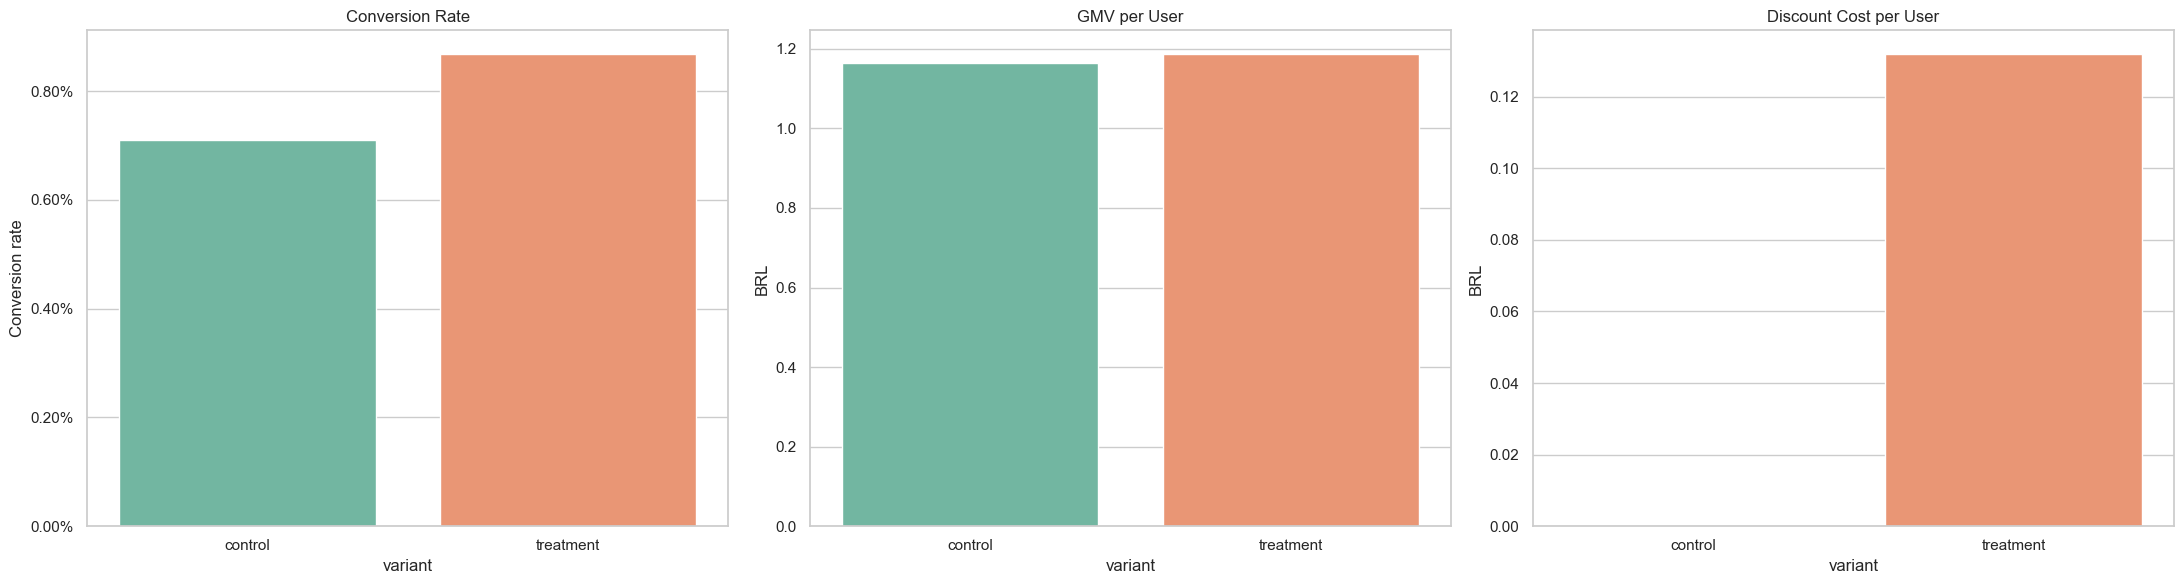

Conversion uplift: 0.16 percentage points
GMV per user uplift: BRL 0.02


In [38]:
from matplotlib.ticker import PercentFormatter

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(
    data=ab_summary,
    x="variant",
    y="conversion_rate",
    palette="Set2",
    ax=axes[0],
)

axes[0].set_title("Conversion Rate")
axes[0].set_ylabel("Conversion rate")
axes[0].yaxis.set_major_formatter(
    PercentFormatter(1)
)

sns.barplot(
    data=ab_summary,
    x="variant",
    y="gmv_per_user",
    palette="Set2",
    ax=axes[1],
)

axes[1].set_title("GMV per User")
axes[1].set_ylabel("BRL")

sns.barplot(
    data=ab_summary,
    x="variant",
    y="discount_cost_per_user",
    palette="Set2",
    ax=axes[2],
)

axes[2].set_title("Discount Cost per User")
axes[2].set_ylabel("BRL")

plt.tight_layout()

plt.savefig(
    "images/ab_test_results.png",
    bbox_inches="tight",
    dpi=300,
)

plt.tight_layout()
plt.show()

conversion_uplift_pp = (
    treatment["conversion"].mean()
    - control["conversion"].mean()
) * 100

gmv_uplift = (
    treatment["net_gmv"].mean()
    - control["net_gmv"].mean()
)

print(
    f"Conversion uplift: {conversion_uplift_pp:.2f} percentage points"
)

print(
    f"GMV per user uplift: BRL {gmv_uplift:.2f}"
)

> Interpretation
> * The treatment group achieves a small but measurable improvement in customer conversion relative to the control group.
> * Despite the conversion uplift, the increase in GMV per user remains minimal once discount effects are incorporated.
> * The experiment highlights an important marketplace trade-off: promotional incentives may improve short-term engagement, but they do not necessarily translate into proportional economic impact.
> * These results suggest that incentive-based growth strategies should be evaluated not only through conversion uplift, but also through margin sustainability and long-term monetization potential.

# 7. Product and Business Strategy

The previous sections focused on understanding marketplace growth, customer behavior, logistics performance, and retention dynamics.

This final section translates those findings into strategic marketplace decisions. The objective is to identify where the business should prioritize investment, operational improvement, retention efforts, and quality control initiatives.

Rather than treating all customers, sellers, and categories equally, the analysis focuses on understanding where marketplace value is concentrated and which areas generate the greatest long-term impact.

## 7.1 Marketplace Value Concentration

Before defining strategic recommendations, it is important to understand where marketplace value is concentrated.

This analysis compares how GMV accumulates across customers, sellers, and categories, helping identify where focused retention, seller management, and assortment decisions can create the highest business impact.

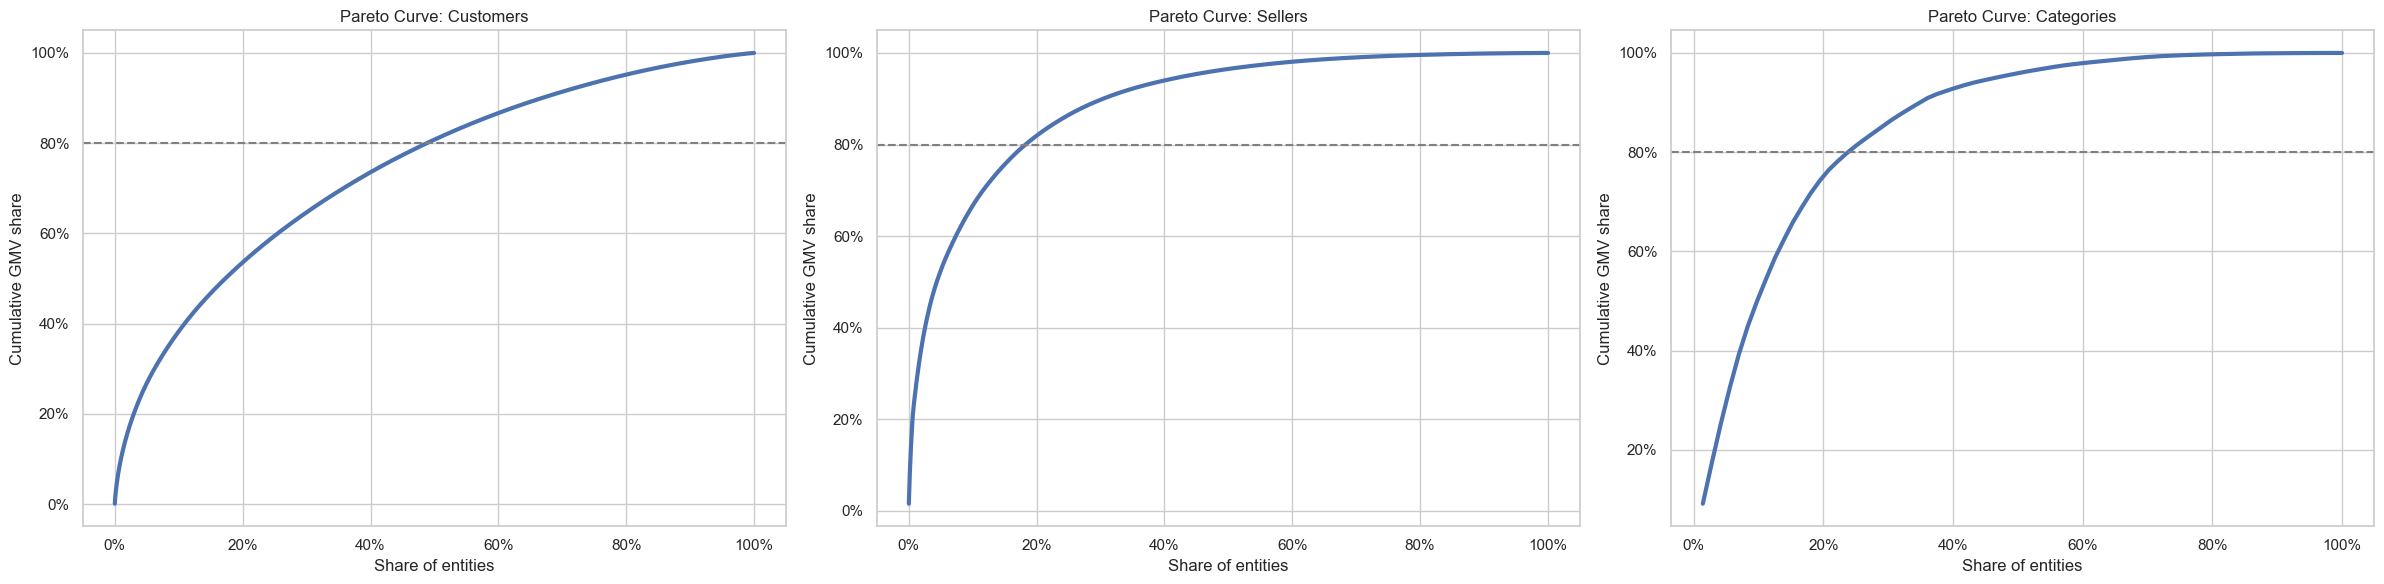

In [27]:
from matplotlib.ticker import PercentFormatter

def pareto_threshold_share(values, target_share=0.80):
    ordered = (
        pd.Series(values)
        .sort_values(ascending=False)
        .reset_index(drop=True)
    )

    cumulative = ordered.cumsum() / ordered.sum()

    return (
        (cumulative <= target_share).sum() + 1
    ) / len(ordered)


customer_80_share = pareto_threshold_share(
    customer_level["realized_ltv"]
)

seller_80_share = pareto_threshold_share(
    seller_summary["gmv"]
)

category_80_share = pareto_threshold_share(
    category_summary["gmv"]
)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

for ax, series, title in [
    (
        axes[0],
        customer_level["realized_ltv"],
        "Customers",
    ),
    (
        axes[1],
        seller_summary["gmv"],
        "Sellers",
    ),
    (
        axes[2],
        category_summary["gmv"],
        "Categories",
    ),
]:
    ordered = (
        pd.Series(series)
        .sort_values(ascending=False)
        .reset_index(drop=True)
    )

    cumulative = ordered.cumsum() / ordered.sum()

    x = (
        ordered.index + 1
    ) / len(ordered)

    ax.plot(x, cumulative, linewidth=3)

    ax.axhline(
        0.8,
        linestyle="--",
        color="gray",
    )

    ax.set_title(f"Pareto Curve: {title}")

    ax.set_xlabel("Share of entities")
    ax.set_ylabel("Cumulative GMV share")

    ax.xaxis.set_major_formatter(
        PercentFormatter(1)
    )

    ax.yaxis.set_major_formatter(
        PercentFormatter(1)
    )

plt.tight_layout()
plt.show()

> Interpretation
> * About 48.8% of customers generate 80% of marketplace GMV, confirming that customer value is meaningfully concentrated and suitable for segmented retention strategies.
> * Roughly 18.3% of sellers account for 80% of GMV, suggesting that seller enablement and quality management can focus on a relatively small strategic group.
> * Approximately 25.0% of categories generate 80% of marketplace GMV, indicating that assortment expansion should remain selective rather than broadly distributed across low-impact categories.

## 7.2 Category Strategy by Customer Value Segment

After identifying where marketplace value is concentrated, the next step is understanding which categories matter most for different customer value segments.

This analysis compares the category mix of high-value and low-value customers, then classifies categories into strategic action groups: invest, fix, or rationalize/monitor.

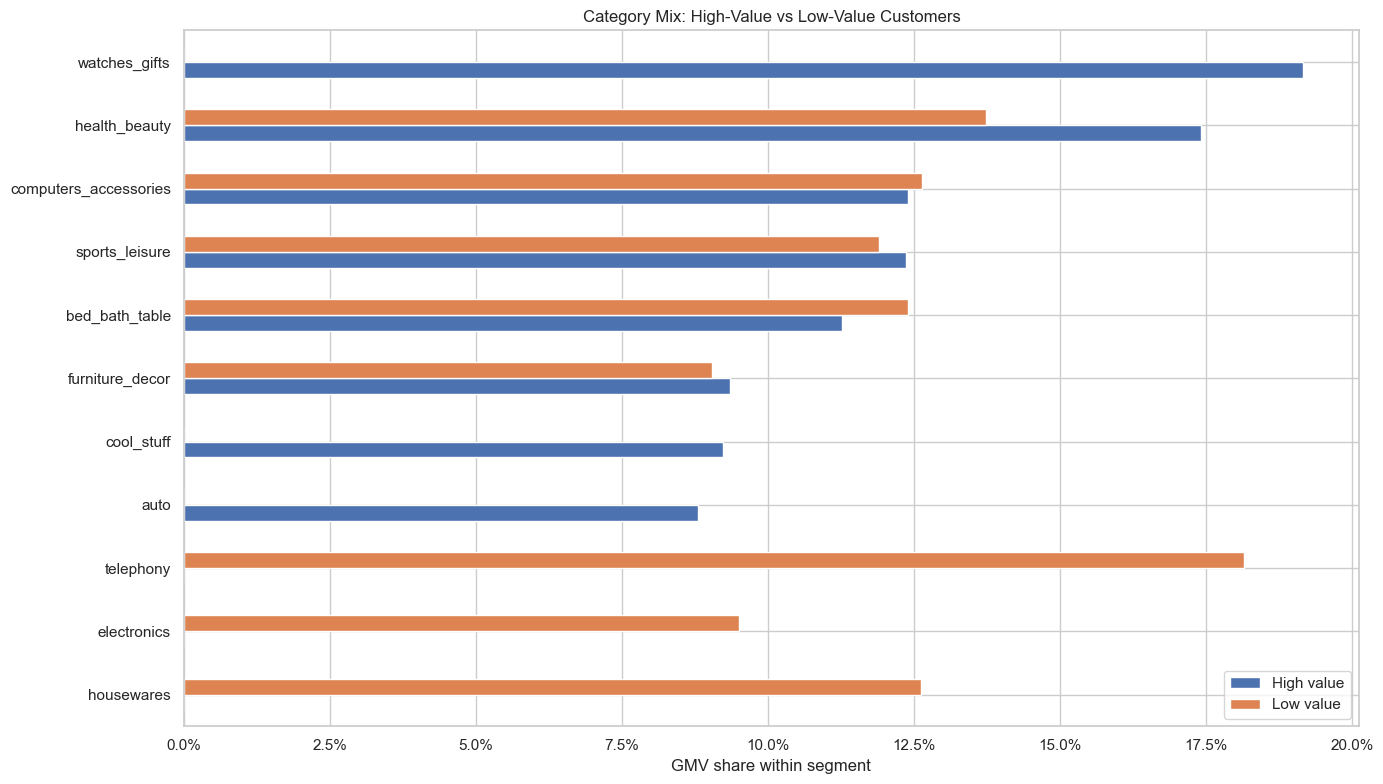

,strategic_action,product_category_name_english,gmv,avg_review,avg_freight_share
0,Fix,watches_gifts,"1,298,292.47",4.03,0.08
1,Fix,bed_bath_table,"1,240,386.13",3.90,0.16
2,Fix,computers_accessories,"1,050,941.58",3.95,0.14
3,Fix,furniture_decor,"899,626.04",3.92,0.19
4,Fix,housewares,"772,035.14",4.07,0.19
5,Invest,health_beauty,"1,437,665.78",4.15,0.13
6,Invest,sports_leisure,"1,147,244.63",4.12,0.15
7,Invest,cool_stuff,"704,086.24",4.16,0.12
8,Invest,auto,"678,606.64",4.08,0.14
9,Invest,toys,"556,783.29",4.18,0.14


In [28]:
from matplotlib.ticker import PercentFormatter

high_value_customers = set(
    customer_level.loc[
        customer_level["value_segment"] == "High",
        "customer_unique_id",
    ]
)

low_value_customers = set(
    customer_level.loc[
        customer_level["value_segment"] == "Low",
        "customer_unique_id",
    ]
)

high_mix = (
    completed_items[
        completed_items["customer_unique_id"]
        .isin(high_value_customers)
    ]
    .groupby("product_category_name_english")["item_gmv"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
)

high_mix = (
    high_mix / high_mix.sum()
).rename("High value")

low_mix = (
    completed_items[
        completed_items["customer_unique_id"]
        .isin(low_value_customers)
    ]
    .groupby("product_category_name_english")["item_gmv"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
)

low_mix = (
    low_mix / low_mix.sum()
).rename("Low value")

mix_compare = (
    pd.concat([high_mix, low_mix], axis=1)
    .fillna(0)
    .sort_values("High value", ascending=True)
)

gmv_high_cutoff = category_summary["gmv"].quantile(0.75)
gmv_low_cutoff = category_summary["gmv"].quantile(0.25)
review_cutoff = category_summary["avg_review"].median()

category_strategy = category_summary[
    [
        "product_category_name_english",
        "gmv",
        "avg_review",
        "avg_freight_share",
    ]
].copy()

category_strategy["strategic_action"] = np.select(
    [
        (
            (category_strategy["gmv"] >= gmv_high_cutoff)
            & (category_strategy["avg_review"] >= review_cutoff)
        ),
        (
            (category_strategy["gmv"] >= gmv_high_cutoff)
            & (category_strategy["avg_review"] < review_cutoff)
        ),
        (
            (category_strategy["gmv"] <= gmv_low_cutoff)
            & (category_strategy["avg_review"] < review_cutoff)
        ),
    ],
    [
        "Invest",
        "Fix",
        "Rationalize / Monitor",
    ],
    default="Maintain",
)

strategy_display = (
    category_strategy[
        category_strategy["strategic_action"] != "Maintain"
    ]
    .sort_values(
        ["strategic_action", "gmv"],
        ascending=[True, False],
    )
    .groupby("strategic_action", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(14, 8))

mix_compare.plot(
    kind="barh",
    ax=ax,
)

ax.set_title(
    "Category Mix: High-Value vs Low-Value Customers"
)

ax.set_xlabel(
    "GMV share within segment"
)

ax.xaxis.set_major_formatter(
    PercentFormatter(1)
)

ax.set_ylabel("")

plt.tight_layout()
plt.show()

display(
    strategy_display[
        [
            "strategic_action",
            "product_category_name_english",
            "gmv",
            "avg_review",
            "avg_freight_share",
        ]
    ]
    .round(2)
)

> Interpretation
> * High-value customers over-index toward lifestyle and discretionary categories such as watches, beauty, sports, and tech accessories, suggesting strong potential for loyalty, personalization, and cross-sell initiatives.
> * Categories classified as **Invest** combine meaningful GMV with stronger review performance, making them good candidates for merchandising, retention, and targeted growth efforts.
> * Categories classified as **Fix** generate strong GMV but show weaker experience indicators, suggesting that operational improvements should come before aggressive growth investment.
> * Categories classified as **Rationalize / Monitor** have lower GMV and weaker satisfaction signals, making them candidates for assortment cleanup, seller remediation, or reduced promotional support.

# 8. Optional Predictive Modeling: GMV Prediction

To keep the notebook practical, the model uses a sample of orders and predicts order-level GMV from basket structure, product mix, seller geography, and payment behavior.

Because marketplace GMV is highly right-skewed, the target variable is log-transformed during training. This reduces the influence of extreme orders, improves numerical stability, and makes the regression task more suitable for tree-based modeling.

This is not a pricing model. It is better interpreted as a forecasting aid for GMV banding, merchandising, and logistics planning.

## Model Dataset Preparation

The predictive model starts by building an order-level modeling dataset from the completed item-level transactions.

To keep the feature space manageable, less frequent product categories and customer/seller states are grouped as **other**. The target variable is order-level GMV, transformed with **log1p** to reduce the effect of extreme order values.

In [29]:
model_items = completed_items.copy()

top_categories_model = (
    model_items["product_category_name_english"]
    .value_counts()
    .head(20)
    .index
)

top_customer_states = (
    model_items["customer_state"]
    .value_counts()
    .head(10)
    .index
)

top_seller_states = (
    model_items["seller_state"]
    .value_counts()
    .head(10)
    .index
)

model_items["category_group"] = (
    model_items["product_category_name_english"]
    .where(
        model_items["product_category_name_english"]
        .isin(top_categories_model),
        "other",
    )
)

model_items["customer_state_group"] = (
    model_items["customer_state"]
    .where(
        model_items["customer_state"]
        .isin(top_customer_states),
        "other",
    )
)

model_items["seller_state_group"] = (
    model_items["seller_state"]
    .where(
        model_items["seller_state"]
        .isin(top_seller_states),
        "other",
    )
)

model_items["payment_type"] = (
    model_items["payment_type"]
    .replace(
        {
            "boleto": "bank_slip",
            "credit_card": "credit_card",
            "debit_card": "debit_card",
            "voucher": "voucher",
        }
    )
)

model_orders = (
    model_items.groupby(
        "order_id",
        as_index=False,
    )
    .agg(
        gmv=("item_gmv", "sum"),
        item_count=("order_item_id", "count"),
        category_count=("category_group", "nunique"),
        main_category=("category_group", mode_or_first),
        avg_weight_g=("product_weight_g", "mean"),
        avg_volume_cm3=("volume_cm3", "mean"),
        seller_count=("seller_id", "nunique"),
        main_seller_state=("seller_state_group", mode_or_first),
        customer_state=("customer_state_group", mode_or_first),
        same_state_share=("same_state_route", "mean"),
        payment_installments=("payment_installments", "max"),
        payment_type=("payment_type", mode_or_first),
    )
)

sample_size = min(40000, len(model_orders))

model_orders = model_orders.sample(
    n=sample_size,
    random_state=42,
)

feature_cols = [
    "item_count",
    "category_count",
    "main_category",
    "avg_weight_g",
    "avg_volume_cm3",
    "seller_count",
    "main_seller_state",
    "customer_state",
    "same_state_share",
    "payment_installments",
    "payment_type",
]

numeric_features = [
    "item_count",
    "category_count",
    "avg_weight_g",
    "avg_volume_cm3",
    "seller_count",
    "same_state_share",
    "payment_installments",
]

categorical_features = [
    "main_category",
    "main_seller_state",
    "customer_state",
    "payment_type",
]

X = model_orders[feature_cols]
y = np.log1p(model_orders["gmv"])

display(
    model_orders[
        feature_cols + ["gmv"]
    ]
    .head()
    .round(2)
)

,item_count,category_count,main_category,avg_weight_g,avg_volume_cm3,seller_count,main_seller_state,customer_state,same_state_share,payment_installments,payment_type,gmv
5718,1,1,computers_accessories,175.00,"8,000.00",1,SP,RS,0.00,2.00,credit_card,196.01
85240,1,1,pet_shop,"1,400.00","24,000.00",1,MG,SP,0.00,1.00,credit_card,96.81
71670,1,1,sports_leisure,"17,650.00","105,840.00",1,SP,SP,1.00,10.00,credit_card,699.94
2544,1,1,other,"2,750.00","9,375.00",1,SP,SP,1.00,1.00,bank_slip,105.37
11006,4,2,baby,"2,675.00","32,560.00",1,SP,RS,0.00,4.00,credit_card,293.64


> Interpretation
> * The modeling dataset combines basket structure, product attributes, seller geography, customer geography, and payment behavior into one row per order.
> * Less frequent categories and states were grouped as **other** to reduce sparsity and keep the model practical.
> * The target variable is order-level GMV, not platform revenue, which keeps the modeling objective consistent with the dataset limitations.
> * Payment types were standardized for readability, with **boleto** represented as **bank_slip**.

## Model Training and Evaluation

The modeling pipeline combines preprocessing and prediction into a single workflow.

Numeric variables use median imputation, while categorical variables are encoded with one-hot encoding. A Random Forest regressor is then trained to predict log-transformed order GMV.

The evaluation focuses on practical business forecasting metrics rather than perfect order-level precision.

In [30]:
(
    X_train,
    X_test,
    y_train,
    y_test,
    gmv_train,
    gmv_test,
) = train_test_split(
    X,
    y,
    model_orders["gmv"],
    test_size=0.25,
    random_state=42,
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    (
                        "imputer",
                        SimpleImputer(strategy="median"),
                    )
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                [
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        ),
                    ),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore"
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

gmv_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=80,
                min_samples_leaf=5,
                max_depth=14,
                random_state=42,
                n_jobs=1,
            ),
        ),
    ]
)

gmv_model.fit(X_train, y_train)

gmv_pred = np.expm1(
    gmv_model.predict(X_test)
)

mae = mean_absolute_error(
    gmv_test,
    gmv_pred,
)

r2 = r2_score(
    gmv_test,
    gmv_pred,
)

median_abs_error = np.median(
    np.abs(gmv_test - gmv_pred)
)

model_metrics = pd.DataFrame(
    {
        "metric": [
            "MAE",
            "Median absolute error",
            "R-squared",
            "Sampled orders",
        ],
        "value": [
            mae,
            median_abs_error,
            r2,
            sample_size,
        ],
    }
)

display(model_metrics.round(2))

,metric,value
0,MAE,63.72
1,Median absolute error,25.85
2,R-squared,0.37
3,Sampled orders,"40,000.00"


> Interpretation
> * The model achieves an MAE of approximately BRL 64 and a median absolute error near BRL 26, indicating that predictions are directionally useful even when individual order forecasts remain noisy.
> * The gap between MAE and median absolute error suggests the presence of some large prediction misses, which is expected in marketplace GMV distributions with heavy outliers.
> * An R-squared of roughly 0.37 indicates that the model captures part of the commercial signal, but a large portion of order variability remains unexplained.
> * The model should therefore be interpreted as a lightweight operational forecasting tool rather than a precise pricing or demand prediction system.

## Model Interpretation and Feature Importance

After training the model, the final step is to inspect prediction behavior and identify which feature groups contribute most to GMV prediction.

The scatterplot compares predicted and actual order GMV, while the feature importance chart summarizes which business dimensions the model relies on most.

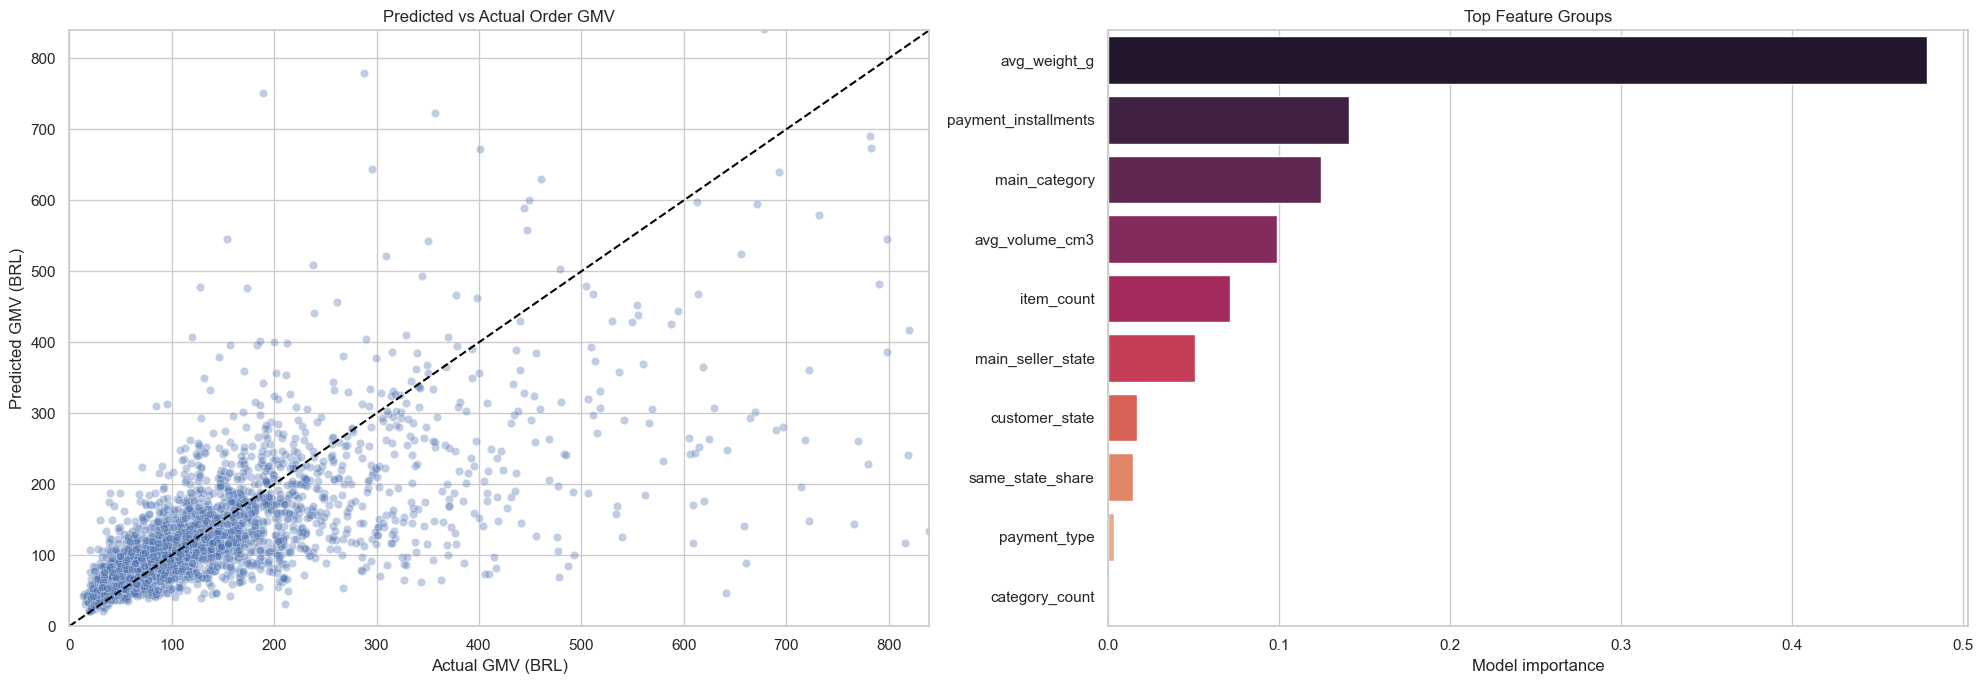

In [37]:
feature_names = (
    gmv_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": (
            gmv_model.named_steps["model"]
            .feature_importances_
        ),
    }
)

def collapse_feature(name):
    cleaned = (
        name.replace("num__", "")
        .replace("cat__", "")
    )

    for original in sorted(
        feature_cols,
        key=len,
        reverse=True,
    ):
        if (
            cleaned == original
            or cleaned.startswith(original + "_")
        ):
            return original

    return cleaned


grouped_importance = (
    importances.assign(
        feature_group=importances["feature"].map(
            collapse_feature
        )
    )
    .groupby(
        "feature_group",
        as_index=False,
    )
    .agg(
        importance=("importance", "sum")
    )
    .sort_values(
        "importance",
        ascending=False,
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 7),
)

plot_sample = (
    pd.DataFrame(
        {
            "actual": gmv_test.reset_index(drop=True),
            "predicted": pd.Series(gmv_pred),
        }
    )
    .sample(
        n=min(3000, len(gmv_test)),
        random_state=42,
    )
)

sns.scatterplot(
    data=plot_sample,
    x="actual",
    y="predicted",
    alpha=0.35,
    ax=axes[0],
)

max_axis = np.percentile(
    np.concatenate(
        [
            plot_sample["actual"],
            plot_sample["predicted"],
        ]
    ),
    99,
)

axes[0].plot(
    [0, max_axis],
    [0, max_axis],
    linestyle="--",
    color="black",
)

axes[0].set_xlim(0, max_axis)
axes[0].set_ylim(0, max_axis)

axes[0].set_title(
    "Predicted vs Actual Order GMV"
)

axes[0].set_xlabel("Actual GMV (BRL)")
axes[0].set_ylabel("Predicted GMV (BRL)")

sns.barplot(
    data=grouped_importance.head(10),
    y="feature_group",
    x="importance",
    palette="rocket",
    ax=axes[1],
)

axes[1].set_title("Top Feature Groups")
axes[1].set_xlabel("Model importance")
axes[1].set_ylabel("")

plt.tight_layout()

plt.savefig(
    "images/predictive_modeling.png",
    bbox_inches="tight",
    dpi=300,
)

plt.tight_layout()
plt.show()

> Interpretation
> * The predicted vs actual plot shows that the model captures the general GMV pattern for lower and mid-range orders, but becomes less precise for higher-value transactions.
> * Feature importance indicates that product weight, payment installments, product category, product volume, and item count are the most influential predictors.
> * Product characteristics and basket structure contribute more to predictive performance than geography alone, reinforcing that marketplace GMV is driven primarily by assortment and order composition.
> * This model is therefore better suited for GMV banding and operational prioritization than precise order-level forecasting.
> * Feature importance in tree-based models reflects predictive contribution rather than direct causal business impact, so these variables should be interpreted as operational signals instead of definitive economic drivers.

# 9. Strategic Recommendations and Business Implications

The final step is to translate the analysis into operational and strategic decisions that could realistically support marketplace growth, retention, and customer experience improvement.


### Key Findings

- Marketplace GMV is diversified enough to avoid dependence on a single category, although a relatively small set of categories and sellers still explains most platform activity.
- **health_beauty** is the largest category by GMV, while **SP** remains the primary demand state of the platform.
- Retention is the main structural weakness of the marketplace: only 3.0% of customers place more than one order, and average month-1 cohort retention is approximately 5.2%.
- Customer value is highly concentrated, with the highest-value segment contributing roughly 59.5% of total GMV.
- Logistics quality has a direct commercial impact, since late deliveries and longer shipping routes are consistently associated with weaker customer review scores.
- Product characteristics and basket composition contribute more to GMV prediction than geography alone, reinforcing the importance of assortment quality and merchandising strategy.


### Strategic Recommendations

- Increase investment in high-scale and high-satisfaction categories such as **health_beauty**, **sports_leisure**, and **cool_stuff** through stronger merchandising, loyalty initiatives, and cross-sell strategies.
- Prioritize operational improvements in large but weaker-experience categories such as **watches_gifts**, **bed_bath_table**, and **computers_accessories**.
- Focus on second-purchase activation programs, since the largest LTV opportunity comes from improving purchase frequency rather than increasing first-order basket size.
- Implement seller quality scorecards combining GMV, review score, and delivery reliability to reduce concentration risk and protect customer trust.
- Explore regional inventory positioning and higher seller density to reduce cross-state logistics friction and freight pressure.


### Trade-Offs and Limitations

- The A/B test is simulated, so statistical significance reflects explicit modeling assumptions rather than causal evidence from a live randomized experiment.
- The predictive model is intentionally lightweight and designed for operational planning support rather than automated pricing or financial forecasting.
- The dataset is historical and does not include contribution margin, advertising spend, or inventory cost data, so profitability conclusions should be interpreted as directional rather than definitive.


### Next Steps

1. Run a real retention experiment targeting customers with high first-order satisfaction but low natural repeat probability.
2. Build seller and category monitoring dashboards combining GMV, late-delivery rate, and customer review metrics.
3. Add contribution margin data to evolve LTV and assortment decisions from GMV-based optimization toward profit-based optimization.